#**Final Project Report**

#**Global Smartphone Sales by Company in 2018-2020**

***ยอดขายสมาร์ทโฟนทั่วโลกจำแนกตามบริษัท ในปี 2018-2020***




## **Description** :

ข้อมูลนี้เป็นข้อมูลเกี่ยวกับจำนวนโทรศัพท์ที่แต่ละบริษัทส่งออกหรือขายในแต่ละไตรมาสตั้งแต่ปี 2018-2020 ซึ่งแต่ละคอลัมน์ในชุดข้อมูล ประกอบด้วย Quarter, ยอดขายโทรศัพท์มือถือจากบริษัท Samsung, Huawei, Xiaomi, Apple, Oppo, Vivo และบริษัทอื่นๆ แบ่งตามไตรมาสและปี

### **Source** :
https://www.kaggle.com/datasets/andrewtgraham/global-phone-sales-by-company-samsung-apple-huawei
<!-- แหล่งข้อมูล : https://www.counterpointresearch.com  -->

<br>

---

# **Part 1 : Setup**

<br>

---

## 1.1 Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from plotnine import *

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1.2 Load dataset

In [ ]:
sales = pd.read_csv('/content/Global Smartphone Sales.csv')
sales

,Quarter,Samsung,Huawei,Xiaomi,Apple,Oppo,Vivo,Others
0,2018Q1,78200000,39300000,28100000,52200000,24200000,18900000,121700000
1,2018Q2,71500000,54200000,32000000,41300000,29600000,26500000,113300000
2,2018Q3,72300000,52000000,33300000,46900000,33900000,30500000,110900000
3,2018Q4,69800000,59700000,25600000,65900000,31300000,26500000,115800000
4,2019Q1,72000000,59100000,27800000,42000000,25700000,23900000,90530000
5,2019Q2,76300000,56600000,32300000,36500000,30600000,27000000,97710000
6,2019Q3,78200000,66800000,31700000,44800000,32300000,31300000,94900000
7,2019Q4,70400000,56200000,32900000,72300000,31400000,31500000,106370000
8,2020Q1,58600000,49000000,29700000,40000000,22300000,21600000,73800000
9,2020Q2,54200000,54800000,26500000,37500000,24500000,22500000,56070000


### **Features** :  
1.   Quarter: ปีและไตรมาส (Q1 = ไตรมาสที่ 1, Q2 = ไตรมาสที่ 2, Q3 = ไตรมาสที่ 3, Q4 = ไตรมาสที่ 4)
2.   Samsung, Huawei, Xiaomi, Apple, Oppo, Vivo, Others: จำนวนการส่งออกโทรศัพท์ในแต่ละไตรมาส


### **Question** :
1. บริษัทใดมียอดขายโทรศัพท์สูงสุดในแต่ละปี?
2. บริษัทใดมียอดขายเฉลี่ยสูงที่สุด?

### **Prediction Task** :

ทำนายยอดขายของโทรศัพท์มือถือในไตรมาสถัดไป โดยพิจารณาจากข้อมูลยอดขายในอดีต


<br>

---

# **Part 2 : EDA**

<br>

---

## 2.1 ตรวจสอบค่า Missing Value

In [ ]:
sales.isnull().sum()

,0
Quarter,0
Samsung,0
Huawei,0
Xiaomi,0
Apple,0
Oppo,0
Vivo,0
Others,0


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Quarter  11 non-null     object
 1   Samsung  11 non-null     int64 
 2   Huawei   11 non-null     int64 
 3   Xiaomi   11 non-null     int64 
 4   Apple    11 non-null     int64 
 5   Oppo     11 non-null     int64 
 6   Vivo     11 non-null     int64 
 7   Others   11 non-null     int64 
dtypes: int64(7), object(1)
memory usage: 832.0+ bytes


จากการตรวจสอบพบว่า ในชุดข้อมูลนี้ไม่มี Missing Value

<br>

---

## 2.2 Melt DataFrame

In [ ]:
sales_melted = pd.melt(sales, id_vars=["Quarter"], var_name="Company", value_name="Sales")
display(sales_melted)

,Quarter,Company,Sales
0,1,Year,2018
1,2,Year,2018
2,3,Year,2018
3,4,Year,2018
4,1,Year,2019
...,...,...,...
83,3,Others,94900000
84,4,Others,106370000
85,1,Others,73800000
86,2,Others,56070000


<br>

---

## 2.3 ตรวจสอบค่า outliers ด้วย boxplot

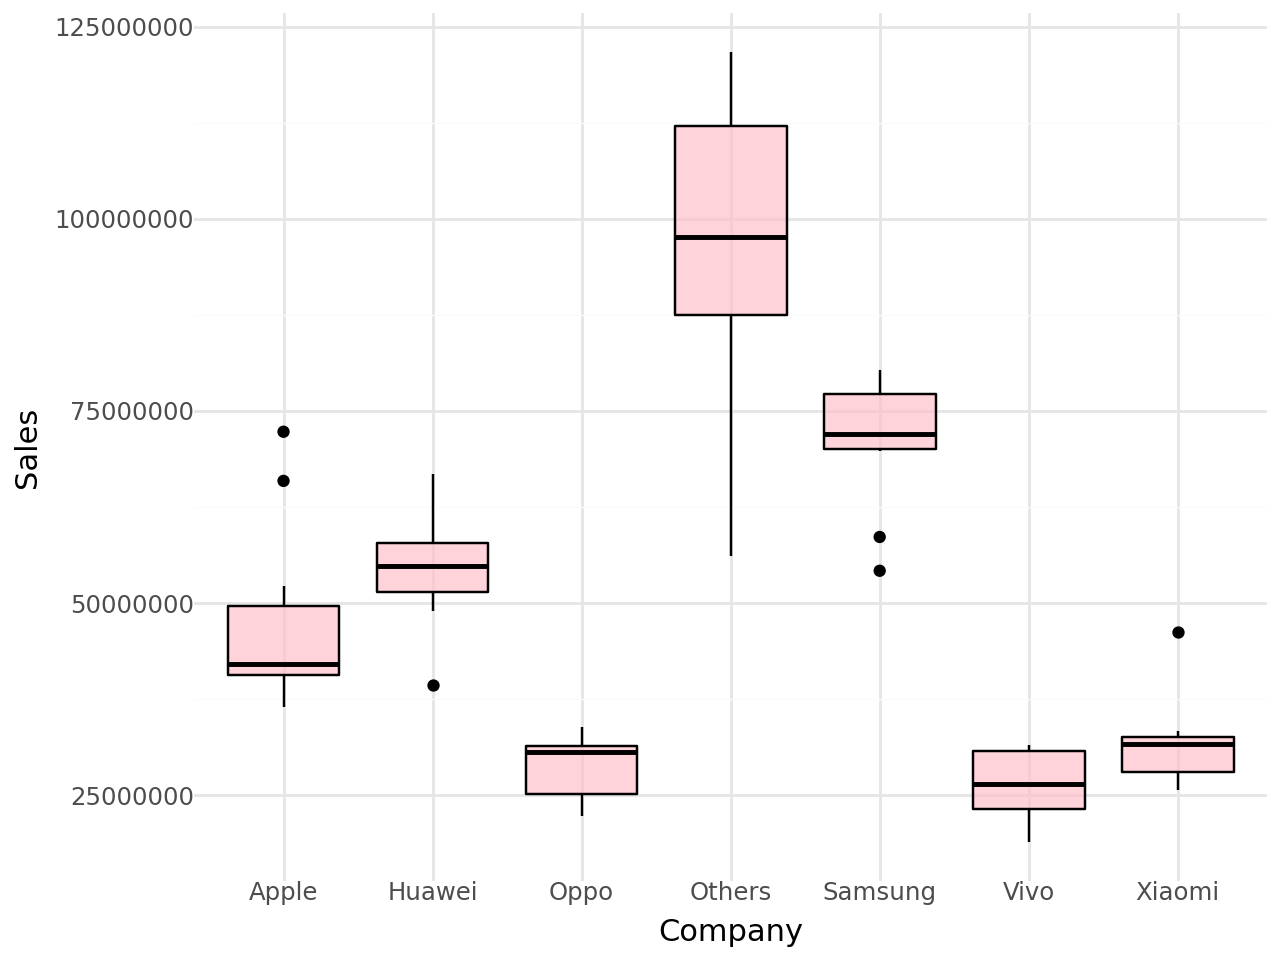

In [ ]:
box_plot = ggplot(sales_melted, aes(x="Company", y="Sales")) + geom_boxplot(fill="pink", color="black", alpha=0.7) + theme_minimal()
display(box_plot)

จากการตรวจสอบพบว่า บริษัทที่มีช่วงยอดขายกว้างที่สุดและค่ามัธยฐานสูงที่สุด คือ บริษัทอื่นๆ (Others) และบริษัท Apple, Samsung, Huawei, Xiaomi มีค่าซึ่งเป็น Outlier ซึ่งอาจแสดงถึงการมีไตรมาสที่ยอดขายห่างจากยอดขายในไตรมาสอื่นๆ

<br>

---

## 2.4 ตรวจสอบการกระจายตัวของยอดขายแต่ละบริษัท

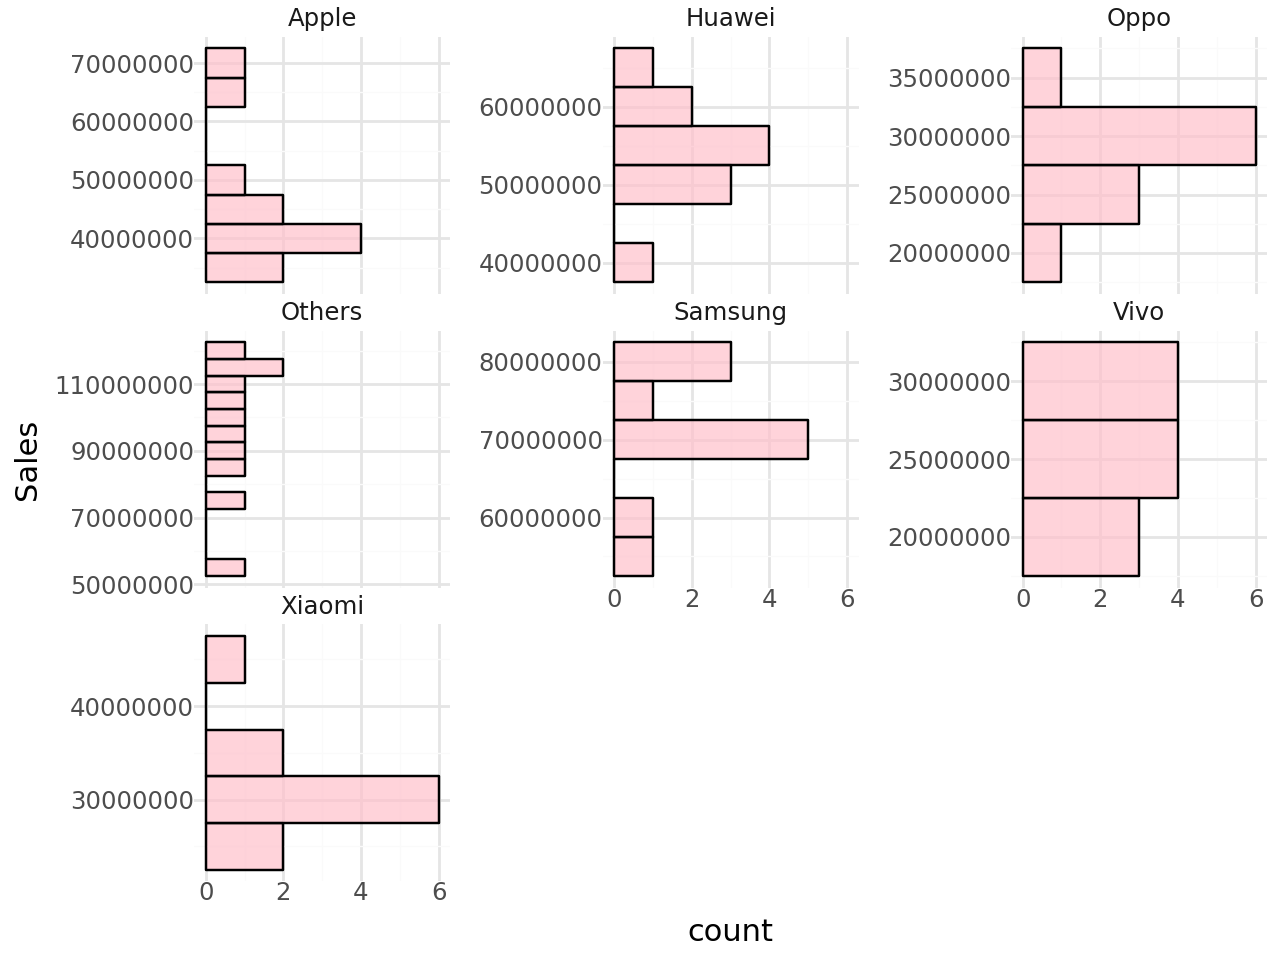

In [ ]:
histogram_plot = (
    ggplot(sales_melted, aes(x="Sales"))
    + geom_histogram(binwidth=5000000, fill="pink", color="black", alpha=0.7)
    + facet_wrap("Company", scales="free_y")
    + coord_flip()
    + theme_minimal()

)
display(histogram_plot)

จากการตรวจสอบพบว่า บริษัทอื่นๆ (Others) มีการกระจายตัวกว้างที่สุด ซึ่งอาจแสดงถึงความหลากหลายของยอดขาย ส่วน Oppo, Vivo, Xiaomi มีการกระจายตัวที่แคบ ซึ่งอาจแสดงถึงความสม่ำเสมอในยอดขายแต่ละไตรมาส

<br>

---

# **Part 3 : Data Processing**

In [ ]:
sales['Year'] = sales['Quarter'].str[:4].astype(int)
sales['Quarter'] = sales['Quarter'].str[5:].astype(int)
move_column = sales.pop('Year')
sales.insert(0, 'Year', move_column)
display(sales)

,Year,Quarter,Samsung,Huawei,Xiaomi,Apple,Oppo,Vivo,Others
0,2018,1,78200000,39300000,28100000,52200000,24200000,18900000,121700000
1,2018,2,71500000,54200000,32000000,41300000,29600000,26500000,113300000
2,2018,3,72300000,52000000,33300000,46900000,33900000,30500000,110900000
3,2018,4,69800000,59700000,25600000,65900000,31300000,26500000,115800000
4,2019,1,72000000,59100000,27800000,42000000,25700000,23900000,90530000
5,2019,2,76300000,56600000,32300000,36500000,30600000,27000000,97710000
6,2019,3,78200000,66800000,31700000,44800000,32300000,31300000,94900000
7,2019,4,70400000,56200000,32900000,72300000,31400000,31500000,106370000
8,2020,1,58600000,49000000,29700000,40000000,22300000,21600000,73800000
9,2020,2,54200000,54800000,26500000,37500000,24500000,22500000,56070000


<br>

---

# **Part 4 : Visualization**

<br>

---

## 4.1 คำถามที่ 1 บริษัทใดมียอดขายโทรศัพท์สูงสุดในแต่ละปี?

In [ ]:
sales_yearly = sales.groupby('Year', as_index=False).sum()
sales_yearly.drop(columns=['Quarter'], inplace=True)
display(sales_yearly)

,Year,Samsung,Huawei,Xiaomi,Apple,Oppo,Vivo,Others
0,2018,291800000,205200000,119000000,206300000,119000000,102400000,461700000
1,2019,296900000,238700000,124700000,195600000,120000000,113700000,389510000
2,2020,193200000,154700000,102400000,119200000,77800000,75100000,214310000


In [ ]:
sales_melted2 = pd.melt(sales_yearly, id_vars=['Year'], value_vars=sales_yearly.columns[1:-1], var_name='Company', value_name='Sales').sort_values(by=['Year', 'Sales'], ascending=[True, True])
sales_melted2_withOthers = pd.melt(sales_yearly, id_vars=['Year'], value_vars=sales_yearly.columns[1:], var_name='Company', value_name='Sales').sort_values(by=['Year', 'Sales'], ascending=[True, True])

max_sales = sales_melted2.loc[sales_melted2.groupby("Year")["Sales"].idxmax()]
max_sales_withOthers = sales_melted2_withOthers.loc[sales_melted2_withOthers.groupby("Year")["Sales"].idxmax()]
max_sales['Label'] = max_sales['Company'] + ' : ' + max_sales['Sales'].astype(str)
max_sales_withOthers['Label'] = max_sales_withOthers['Company'] + ' : ' + max_sales_withOthers['Sales'].astype(str)

display(sales_melted2)
display(sales_melted2_withOthers)
# display(max_sales)
# display(max_sales_withOthers)

,Year,Company,Sales
15,2018,Vivo,102400000
6,2018,Xiaomi,119000000
12,2018,Oppo,119000000
3,2018,Huawei,205200000
9,2018,Apple,206300000
0,2018,Samsung,291800000
16,2019,Vivo,113700000
13,2019,Oppo,120000000
7,2019,Xiaomi,124700000
10,2019,Apple,195600000


,Year,Company,Sales
15,2018,Vivo,102400000
6,2018,Xiaomi,119000000
12,2018,Oppo,119000000
3,2018,Huawei,205200000
9,2018,Apple,206300000
0,2018,Samsung,291800000
18,2018,Others,461700000
16,2019,Vivo,113700000
13,2019,Oppo,120000000
7,2019,Xiaomi,124700000


In [ ]:
sales_melted2['Company'] = pd.Categorical(sales_melted2['Company'], categories=sales_melted2['Company'].unique(), ordered=True)
sales_melted2_withOthers['Company'] = pd.Categorical(sales_melted2_withOthers['Company'], categories=sales_melted2_withOthers['Company'].unique(), ordered=True)

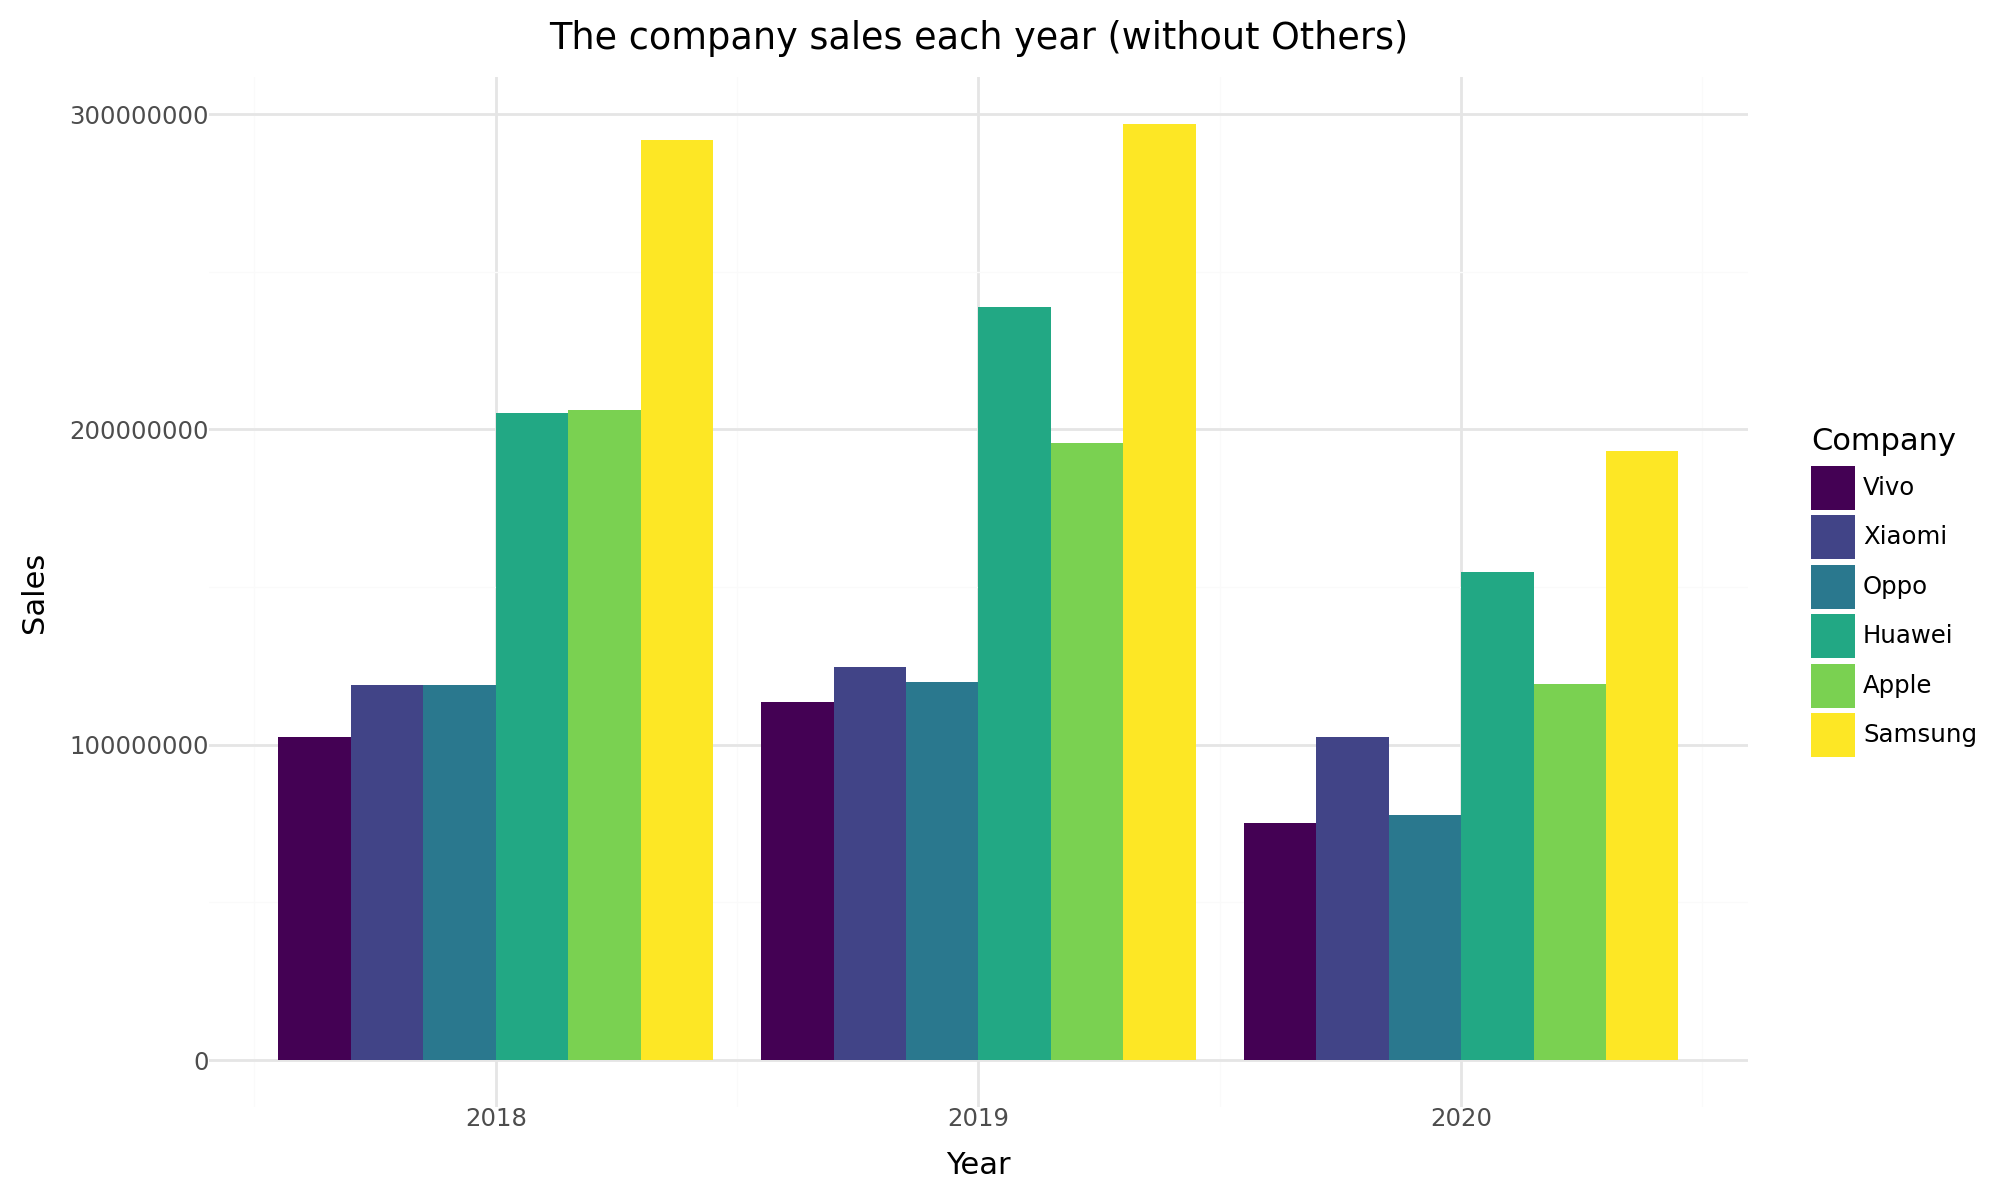

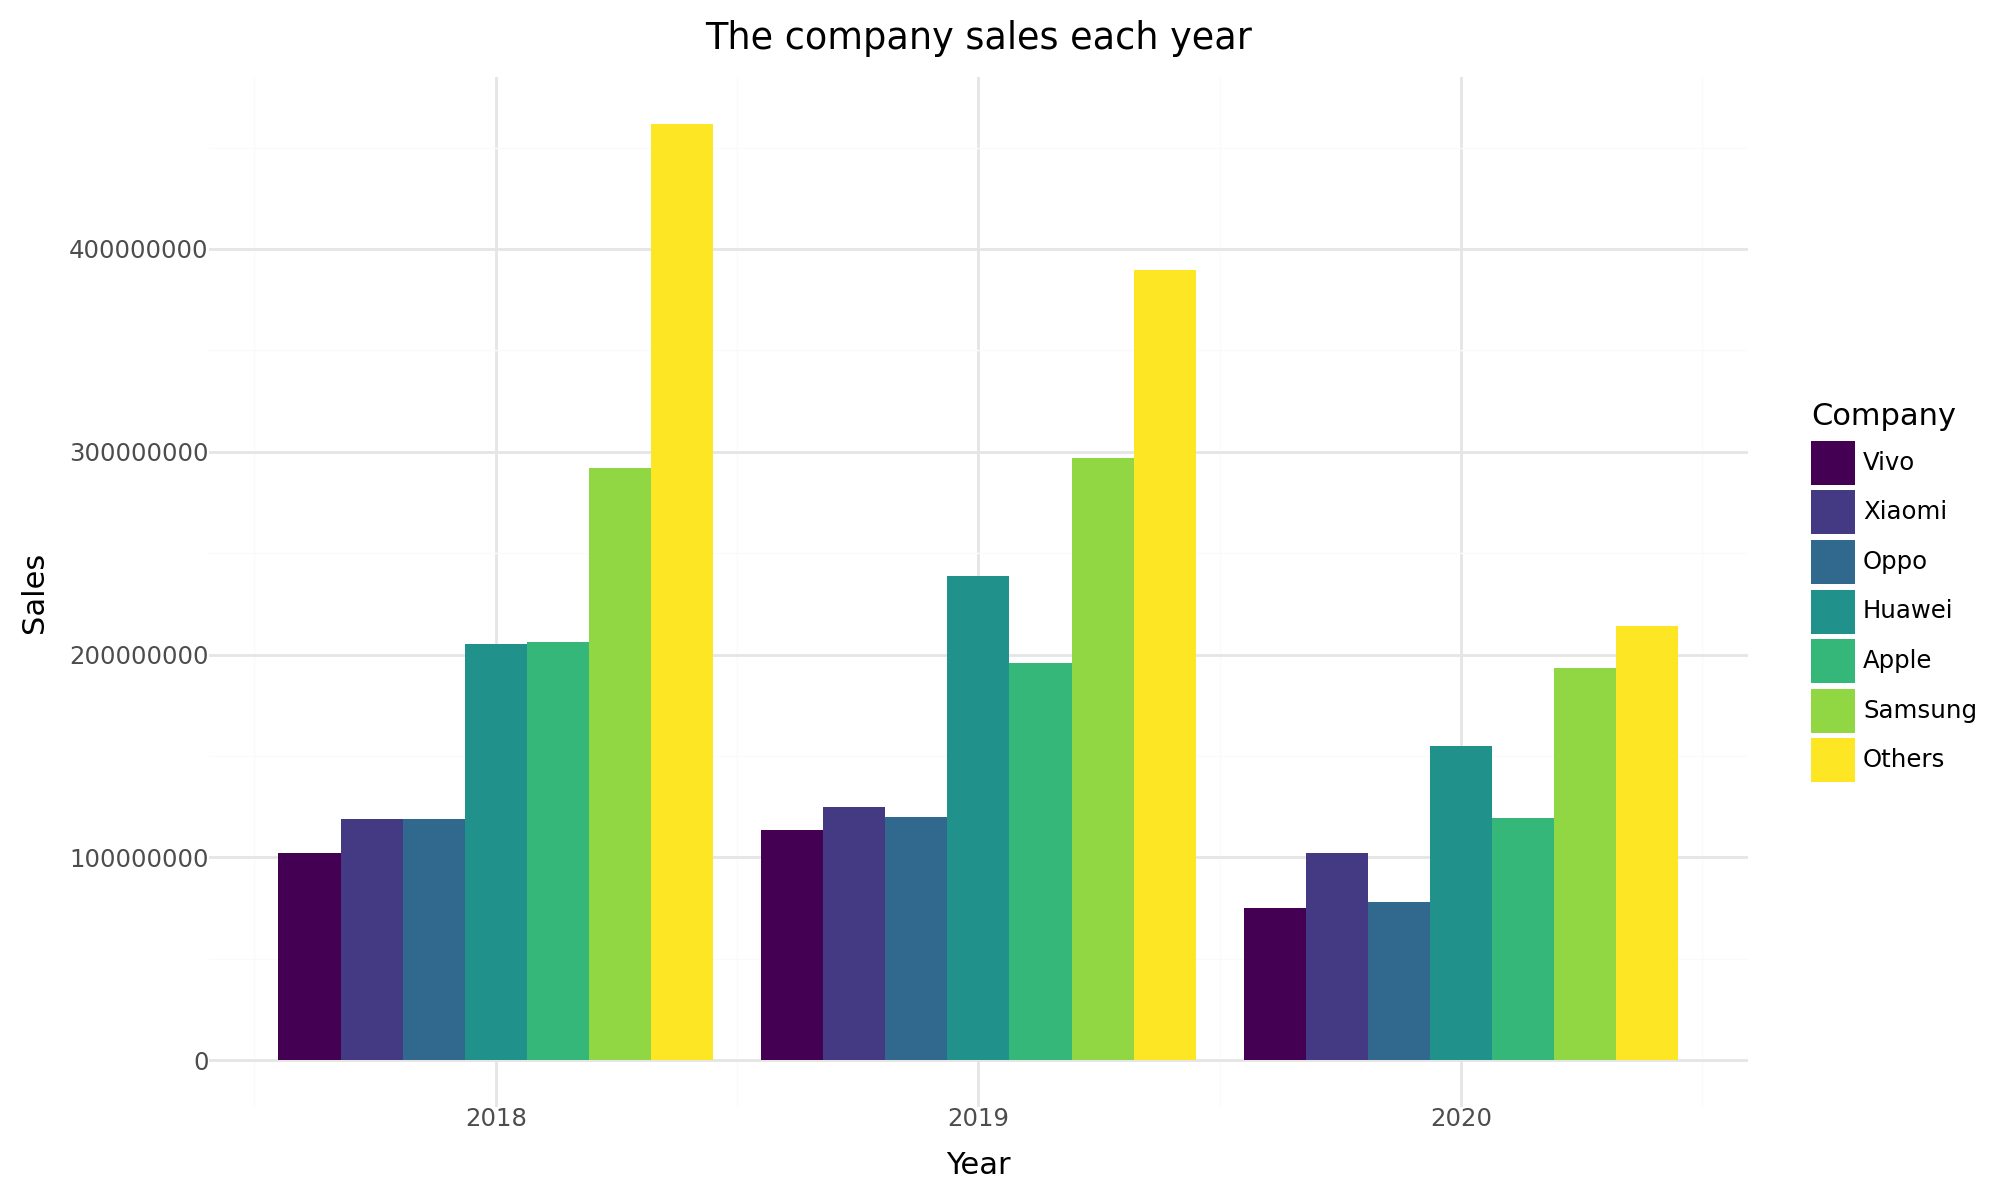

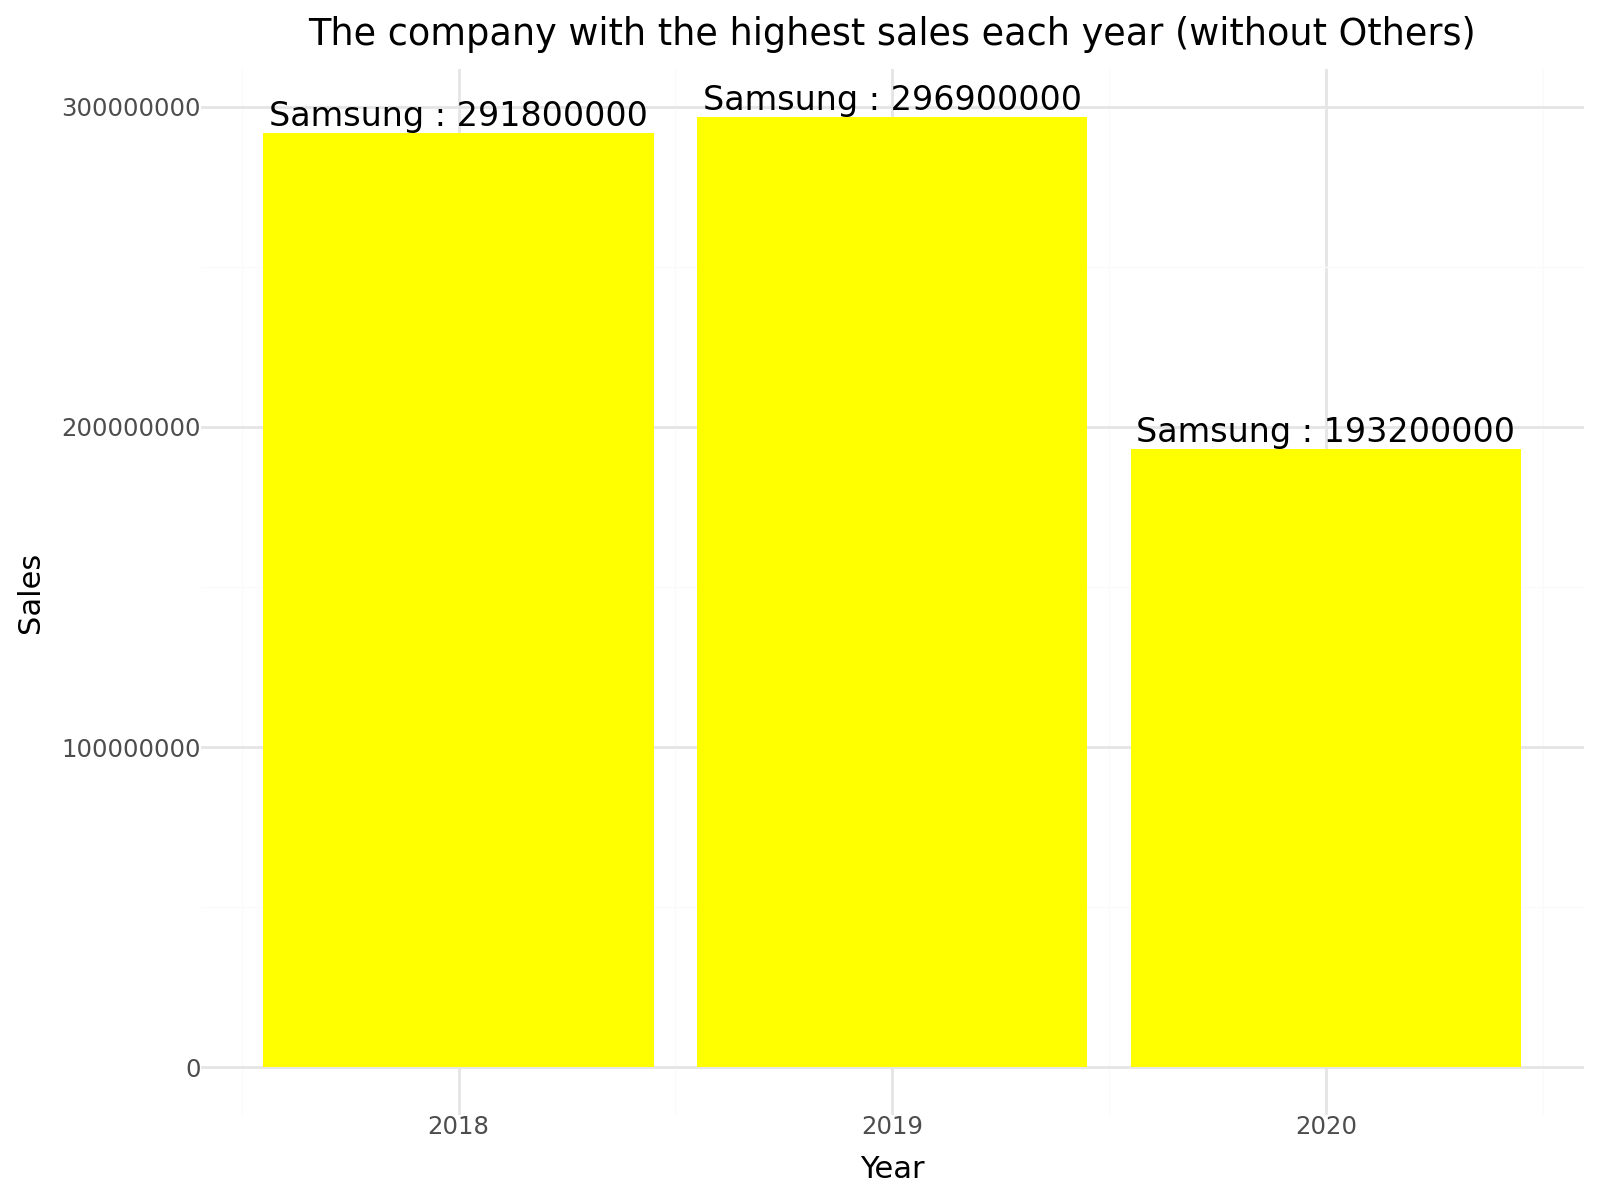

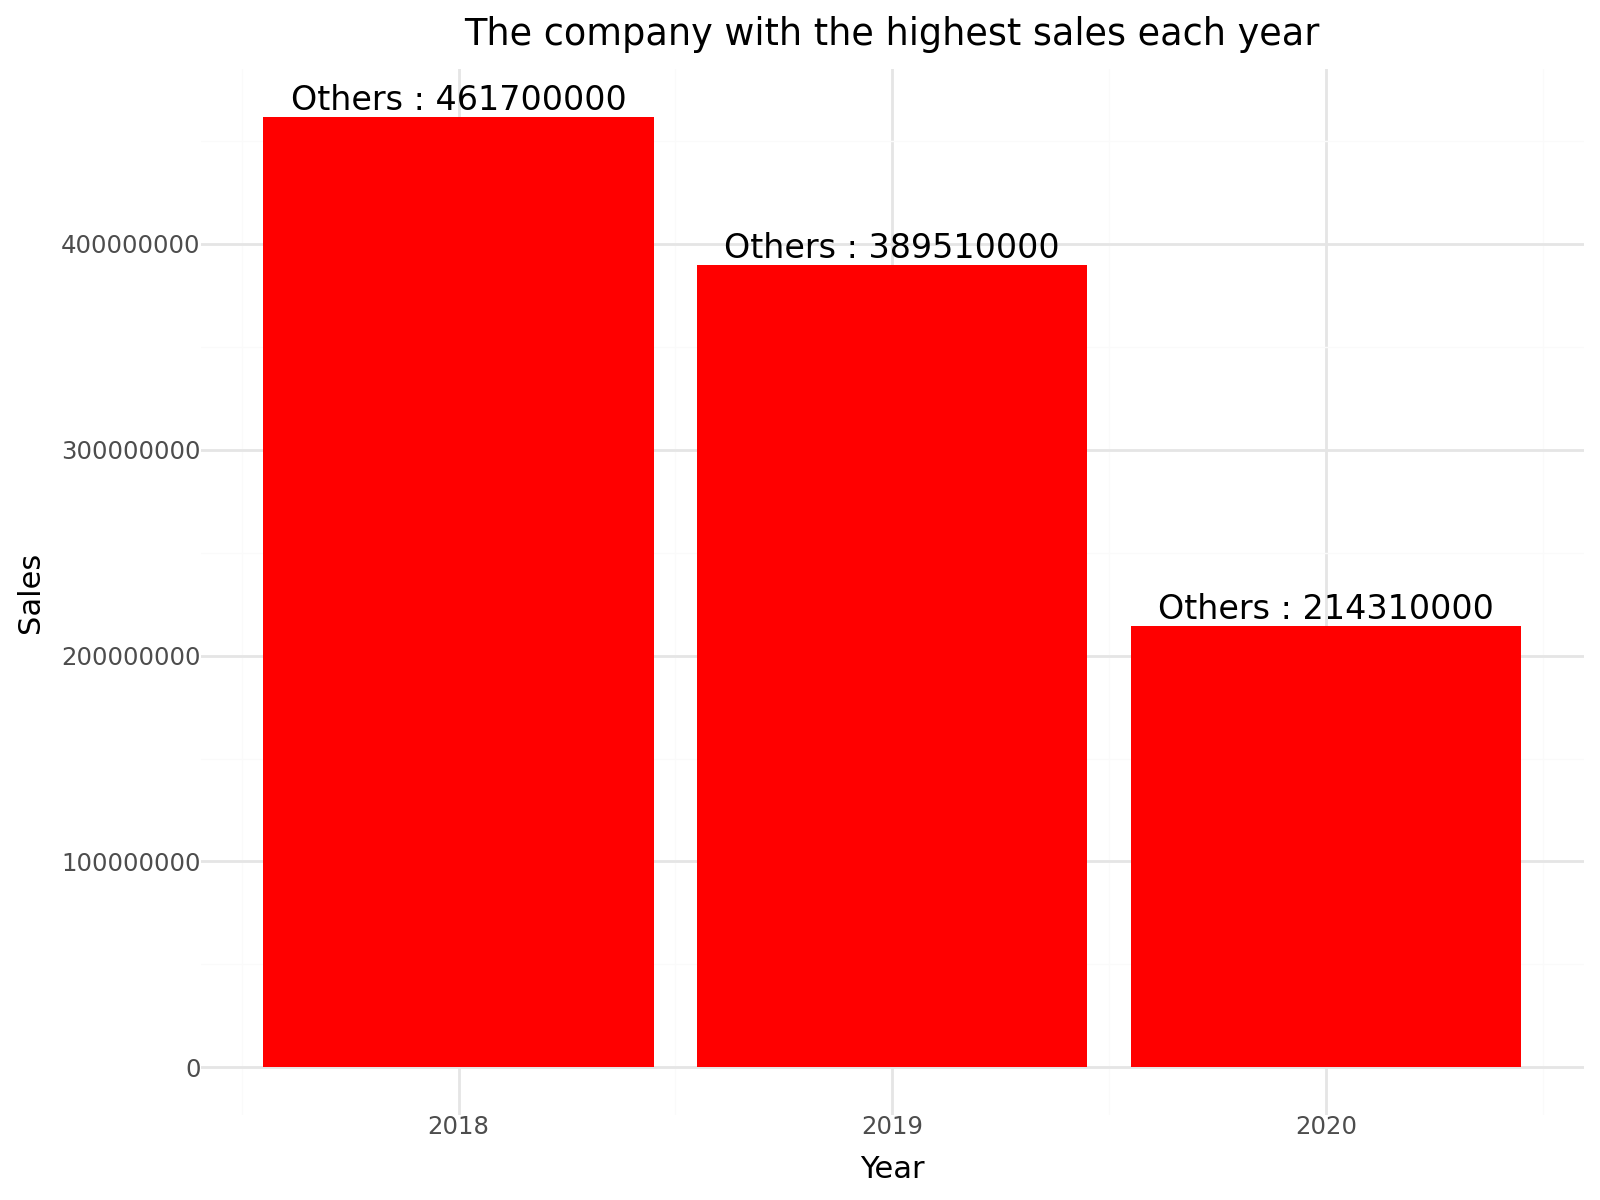

In [ ]:
sales_plot = (
    ggplot(sales_melted2, aes(x='Year', y='Sales', fill='Company')) +
    geom_bar(stat='identity', position='dodge') +
    theme_minimal() +
    theme(figure_size=(10, 6)) +
    labs(title="The company sales each year (without Others)", x="Year", y="Sales")
)

sales_melted2_withOthers = (
    ggplot(sales_melted2_withOthers, aes(x='Year', y='Sales', fill='Company')) +
    geom_bar(stat='identity', position='dodge') +
    theme_minimal() +
    theme(figure_size=(10, 6)) +
    labs(title="The company sales each year", x="Year", y="Sales")
)

max_sales_plot = (
    ggplot(max_sales, aes(x='Year', y='Sales', fill='Company')) +
    geom_bar(stat='identity', position='dodge', fill='yellow') +
    geom_text(aes(label='Label'), position='stack', va='bottom', size=12) +
    theme_minimal() +
    theme(figure_size=(8, 6)) +
    labs(title="The company with the highest sales each year (without Others)", x="Year", y="Sales")
)
max_sales_withOthers_plot = (
    ggplot(max_sales_withOthers, aes(x='Year', y='Sales', fill='Company')) +
    geom_bar(stat='identity', position='dodge', fill='red') +
    geom_text(aes(label='Label'), position='stack', va='bottom', size=12) +
    theme_minimal() +
    theme(figure_size=(8, 6)) +
    labs(title="The company with the highest sales each year", x="Year", y="Sales")
)

display(sales_plot)
display(sales_melted2_withOthers)
display(max_sales_plot)
display(max_sales_withOthers_plot)

<br>

---

## 4.2 คำถามที่ 2 บริษัทใดมียอดขายเฉลี่ยสูงที่สุด?

In [ ]:
average_sales = sales.iloc[:, 2:].mean().reset_index()
average_sales.columns = ['Company', 'AverageSales']
average_sales = average_sales.sort_values(by='AverageSales', ascending=True)
average_sales['Company'] = pd.Categorical(average_sales['Company'], categories=average_sales['Company'], ordered=True)
display(average_sales)

,Company,AverageSales
5,Vivo,2.647273e+07
4,Oppo,2.880000e+07
2,Xiaomi,3.146364e+07
3,Apple,4.737273e+07
1,Huawei,5.441818e+07
0,Samsung,7.108182e+07
6,Others,9.686545e+07


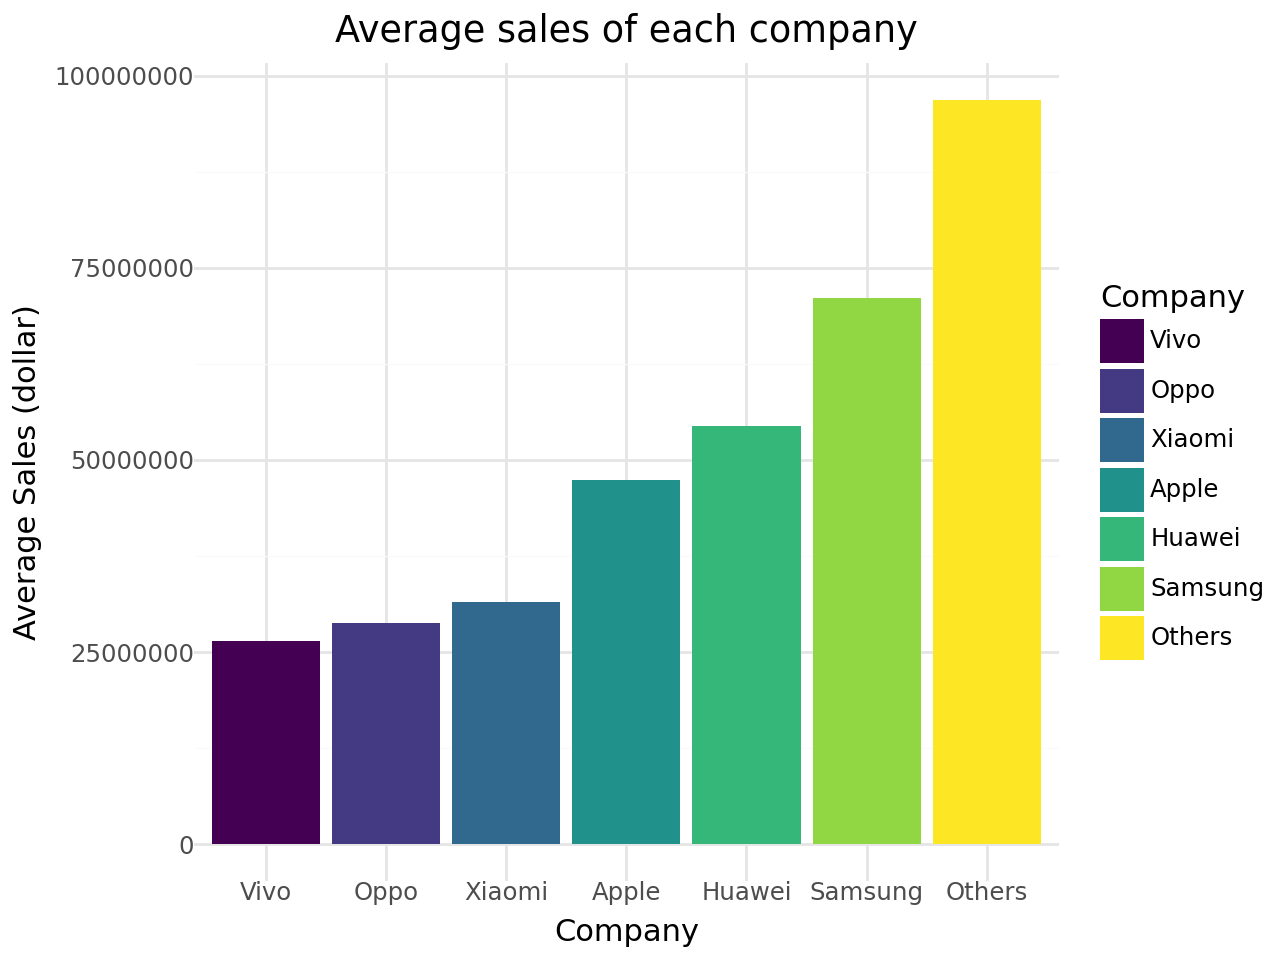

In [ ]:
average_plot = (
    ggplot(average_sales, aes(x='Company', y='AverageSales', fill='Company')) +
    geom_bar(stat='identity', position='dodge') +
    labs(title="Average sales of each company", x="Company", y="Average Sales (dollar)") +
    theme_minimal()
)

display(average_plot)

<br>

---

# **Part 5 : Prediction Task**
# **ทำนายยอดขายของโทรศัพท์มือถือในไตรมาสถัดไป โดยพิจารณาจากข้อมูลยอดขายในอดีต**


<br>

---
*แบ่งการทำนายออกทีละบริษัทโดยยกตัวอย่างการทำนาย Apple*
## ทำนายยอดขายโทรศัพท์มือถือในไตรมาสถัดไป ของ Apple


## 5.1 Split Training/Testing

In [ ]:
# สร้าง Lag Features
apple_features = sales[['Year', 'Quarter', 'Apple']]
apple_model = apple_features.copy()
apple_model['Apple_Lag1'] = apple_model['Apple'].shift(1)
apple_model['Apple_Lag2'] = apple_model['Apple'].shift(2)
apple_model.dropna(inplace=True)  # ลบ NaN ที่เกิดจากการ shift
apple_model['Apple_Lag1'] = apple_model['Apple_Lag1'].astype(int)
apple_model['Apple_Lag2'] = apple_model['Apple_Lag2'].astype(int)
display(apple_model)

,Year,Quarter,Apple,Apple_Lag1,Apple_Lag2
2,2018,3,46900000,41300000,52200000
3,2018,4,65900000,46900000,41300000
4,2019,1,42000000,65900000,46900000
5,2019,2,36500000,42000000,65900000
6,2019,3,44800000,36500000,42000000
7,2019,4,72300000,44800000,36500000
8,2020,1,40000000,72300000,44800000
9,2020,2,37500000,40000000,72300000
10,2020,3,41700000,37500000,40000000


**Feature ที่ใช้ในการทำนาย คือ Apple_Lag1 และ Apple_Lag2**

In [ ]:
X = apple_model[['Apple_Lag1', 'Apple_Lag2']]
y = apple_model['Apple']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)
print(X_train.shape)
print(X_test.shape)

(7, 2)
(2, 2)


## 5.2 Cross Validation

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression_alpha=1': Ridge(alpha=1.0),
    'Ridge Regression_alpha=.5': Ridge(alpha=.5),
    'Lasso Regression_alpha=1': Lasso(alpha=1.0),
    'Lasso Regression_alpha=.5': Lasso(alpha=.5)
}

cv_results = []

for model_name, model in models.items():
  cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
  mean_cv_mse = -cv_scores.mean()
  cv_results.append({
      'Model': model_name,
      'Mean CV MSE': mean_cv_mse,
  })

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

                       Model   Mean CV MSE
0          Linear Regression  9.387677e+14
1   Ridge Regression_alpha=1  9.387677e+14
2  Ridge Regression_alpha=.5  9.387677e+14
3   Lasso Regression_alpha=1  9.387677e+14
4  Lasso Regression_alpha=.5  9.387677e+14


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.914e+11, tolerance: 1.219e+11
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.758e+12, tolerance: 1.219e+11


## 5.3 Fit model

In [ ]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)

LinearRegression()

## 5.4 เตรียมข้อมูลและประเมิณผล

In [ ]:
future_quarters = pd.DataFrame({
    'Year': [2020] * 1 + [2021] * 4,
    'Quarter': [4] + [1, 2, 3, 4],
    'Apple_Lag1': [apple_model['Apple'].iloc[-1], np.nan, np.nan, np.nan, np.nan],
    'Apple_Lag2': [apple_model['Apple'].iloc[-2], apple_model['Apple'].iloc[-1], np.nan, np.nan, np.nan]
})

# สร้างเงื่อนไขสำหรับทำนายทีละไตรมาส
for i in range(len(future_quarters)):
    if i > 0:
        future_quarters.loc[i, 'Apple_Lag1'] = future_quarters.loc[i - 1, 'Predicted_Apple']
        future_quarters.loc[i, 'Apple_Lag2'] = future_quarters.loc[i - 1, 'Apple_Lag1']
    future_quarters.loc[i, 'Predicted_Apple'] = best_model.predict(
        future_quarters[['Apple_Lag1', 'Apple_Lag2']].iloc[i:i+1]
    )[0]

# ทำนายผลบน Test Set
y_pred = best_model.predict(X_test)

# ประเมิณผล
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse}")
print(f"R2: {r2_score(y_train, best_model.predict(X_train))}")

RMSE: 10785022.43068123
R2: 0.5116830003212591


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


## 5.5 Plot Graph



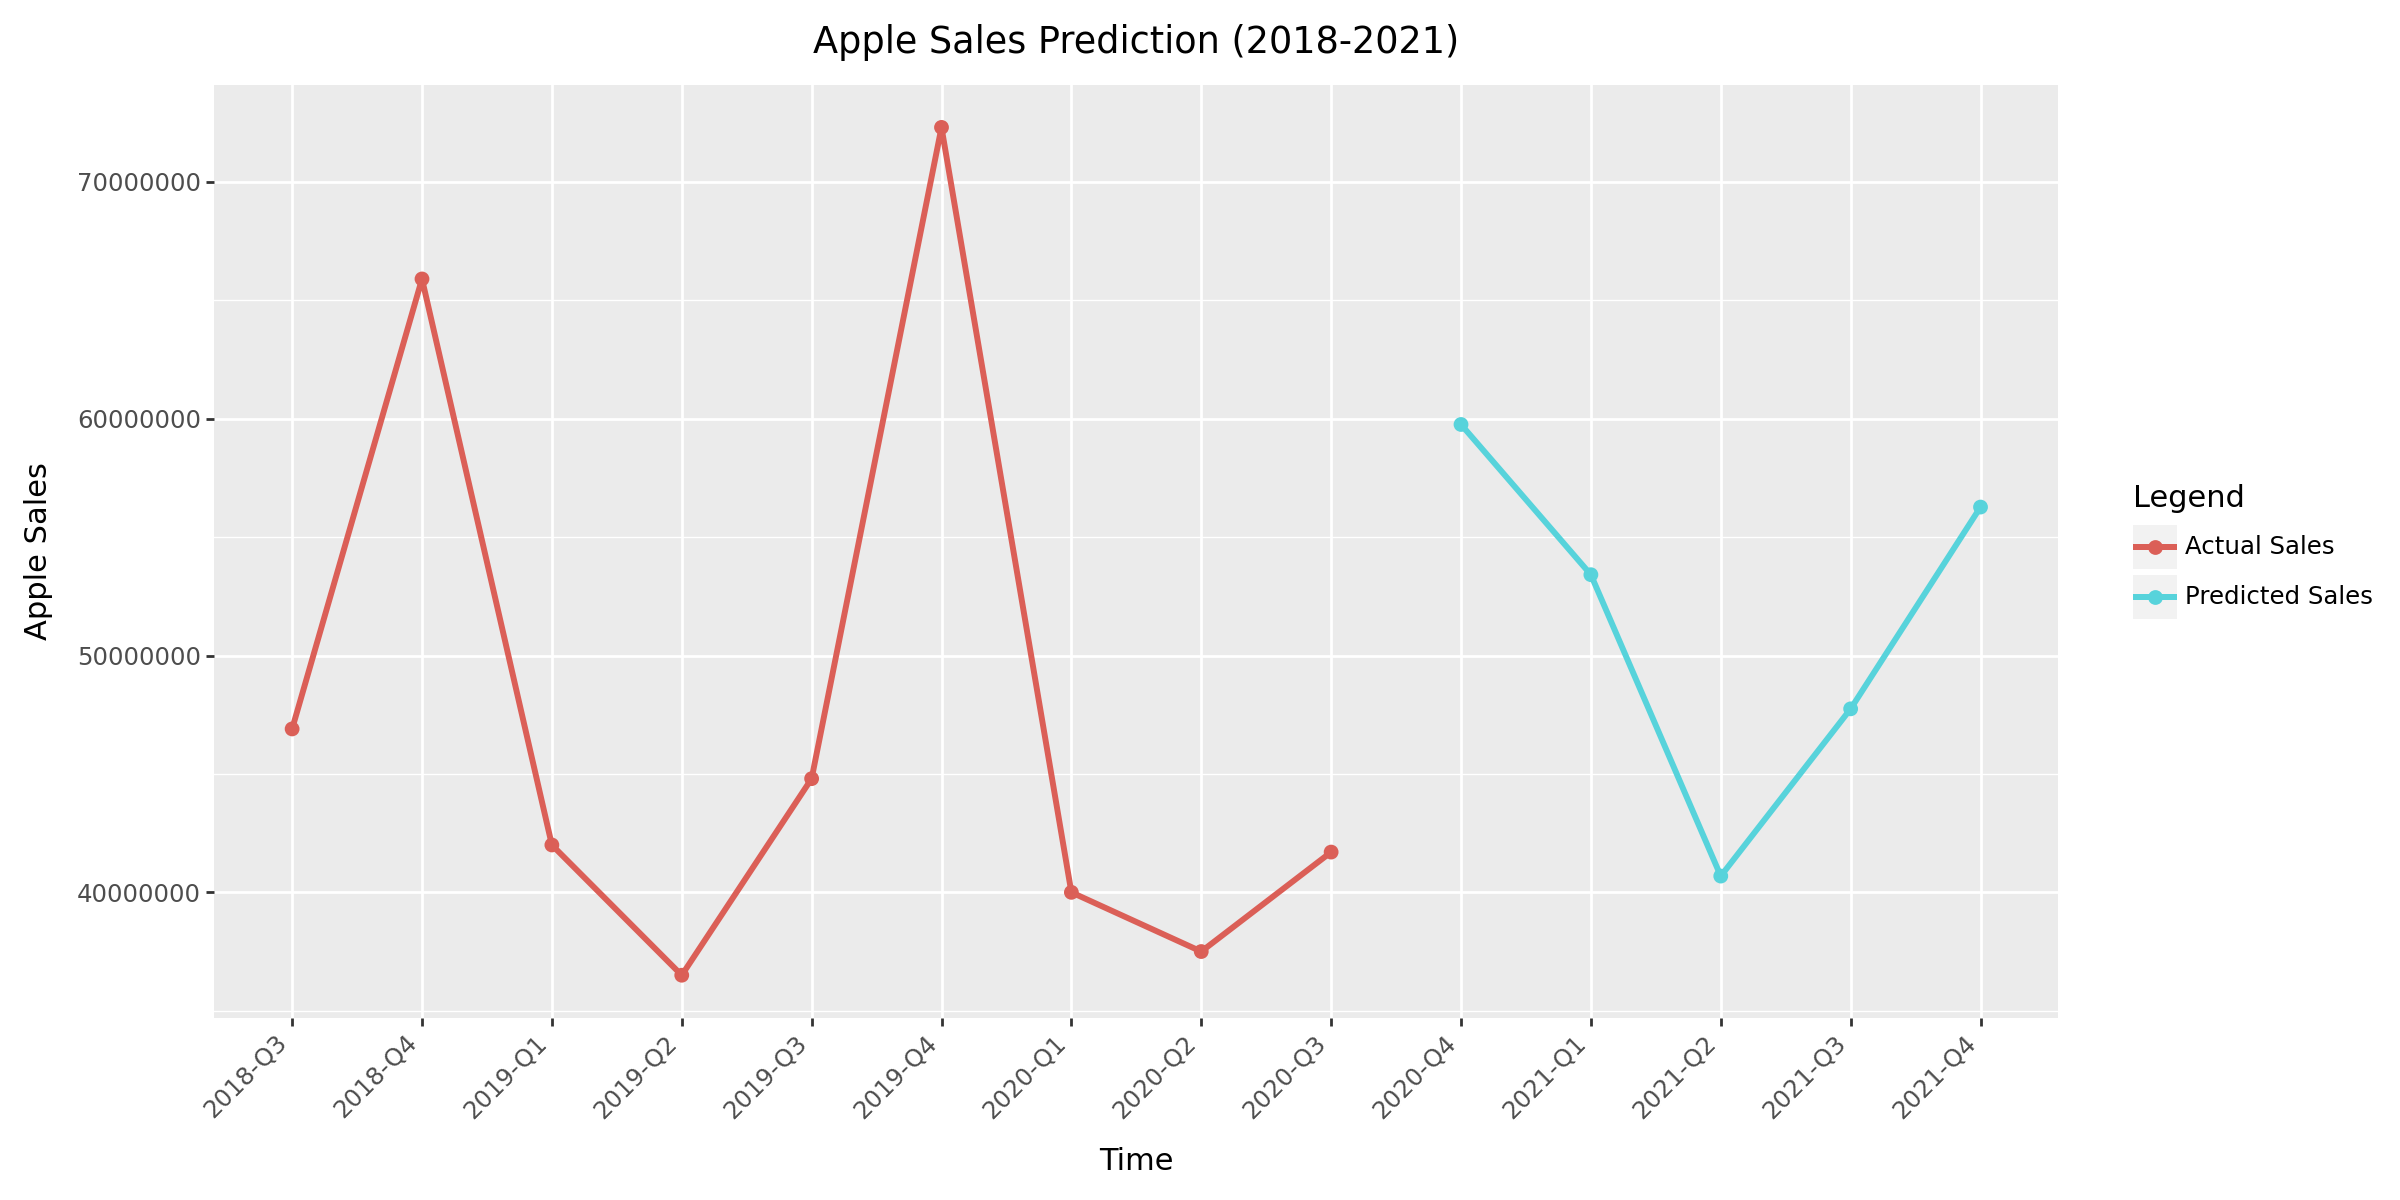

In [ ]:
# รวมข้อมูลจริงกับข้อมูลทำนาย
future_quarters['Apple'] = np.nan  # กำหนด Apple เป็น NaN สำหรับข้อมูลทำนาย
df_combined = pd.concat([apple_model, future_quarters], ignore_index=True)

# สร้างคอลัมน์ Time ในการบอกปีและไตรมาส
df_combined['Time'] = df_combined['Year'].astype(str) + '-Q' + df_combined['Quarter'].astype(str)

df_combined['Type'] = np.where(df_combined['Apple'].isna(), 'Predicted Sales', 'Actual Sales')
df_combined['Sales'] = df_combined['Apple'].fillna(df_combined['Predicted_Apple'])

apple_plot = (
    ggplot(df_combined, aes(x="Time", y="Sales", color="Type", group="Type"))
    + geom_line(size=1.2)
    + geom_point(size=2)
    + labs(
        title="Apple Sales Prediction (2018-2021)",
        x="Time",
        y="Apple Sales",
        color="Legend"
    )
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(12, 6)
    )
)
display(apple_plot)


## ผลการทำนายของบริษัท Samsung, Huawei, Xiaomi, Oppo, Vivo, Others

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Samsung RMSE: 2514993.8223552075
Samsung R2: 0.5145925849550403


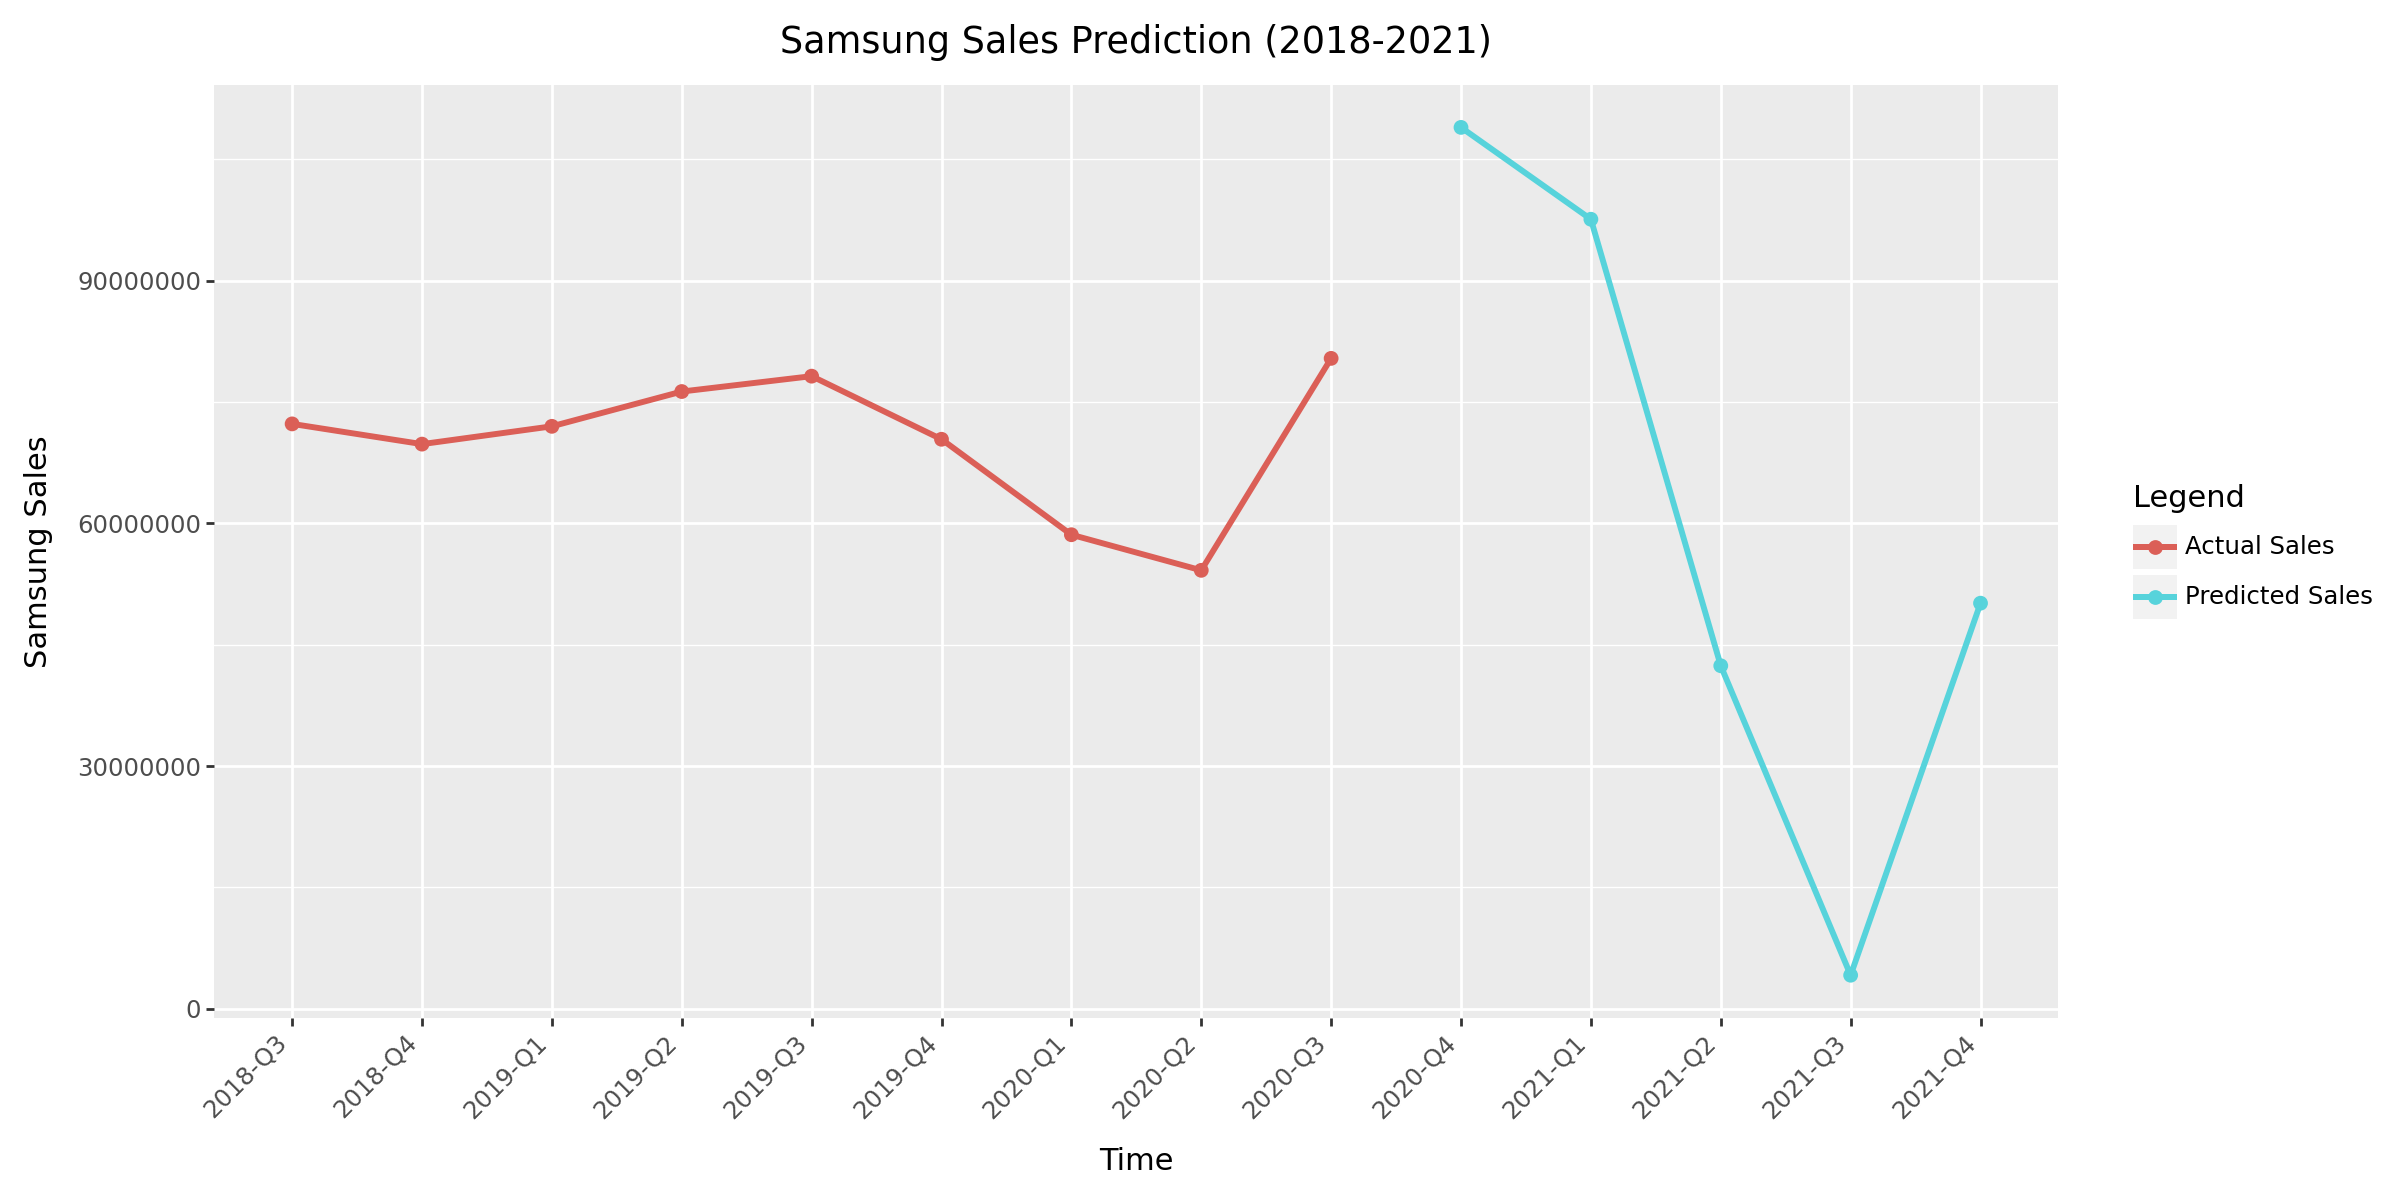

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Huawei RMSE: 9952673.393442022
Huawei R2: 0.3242155744701777


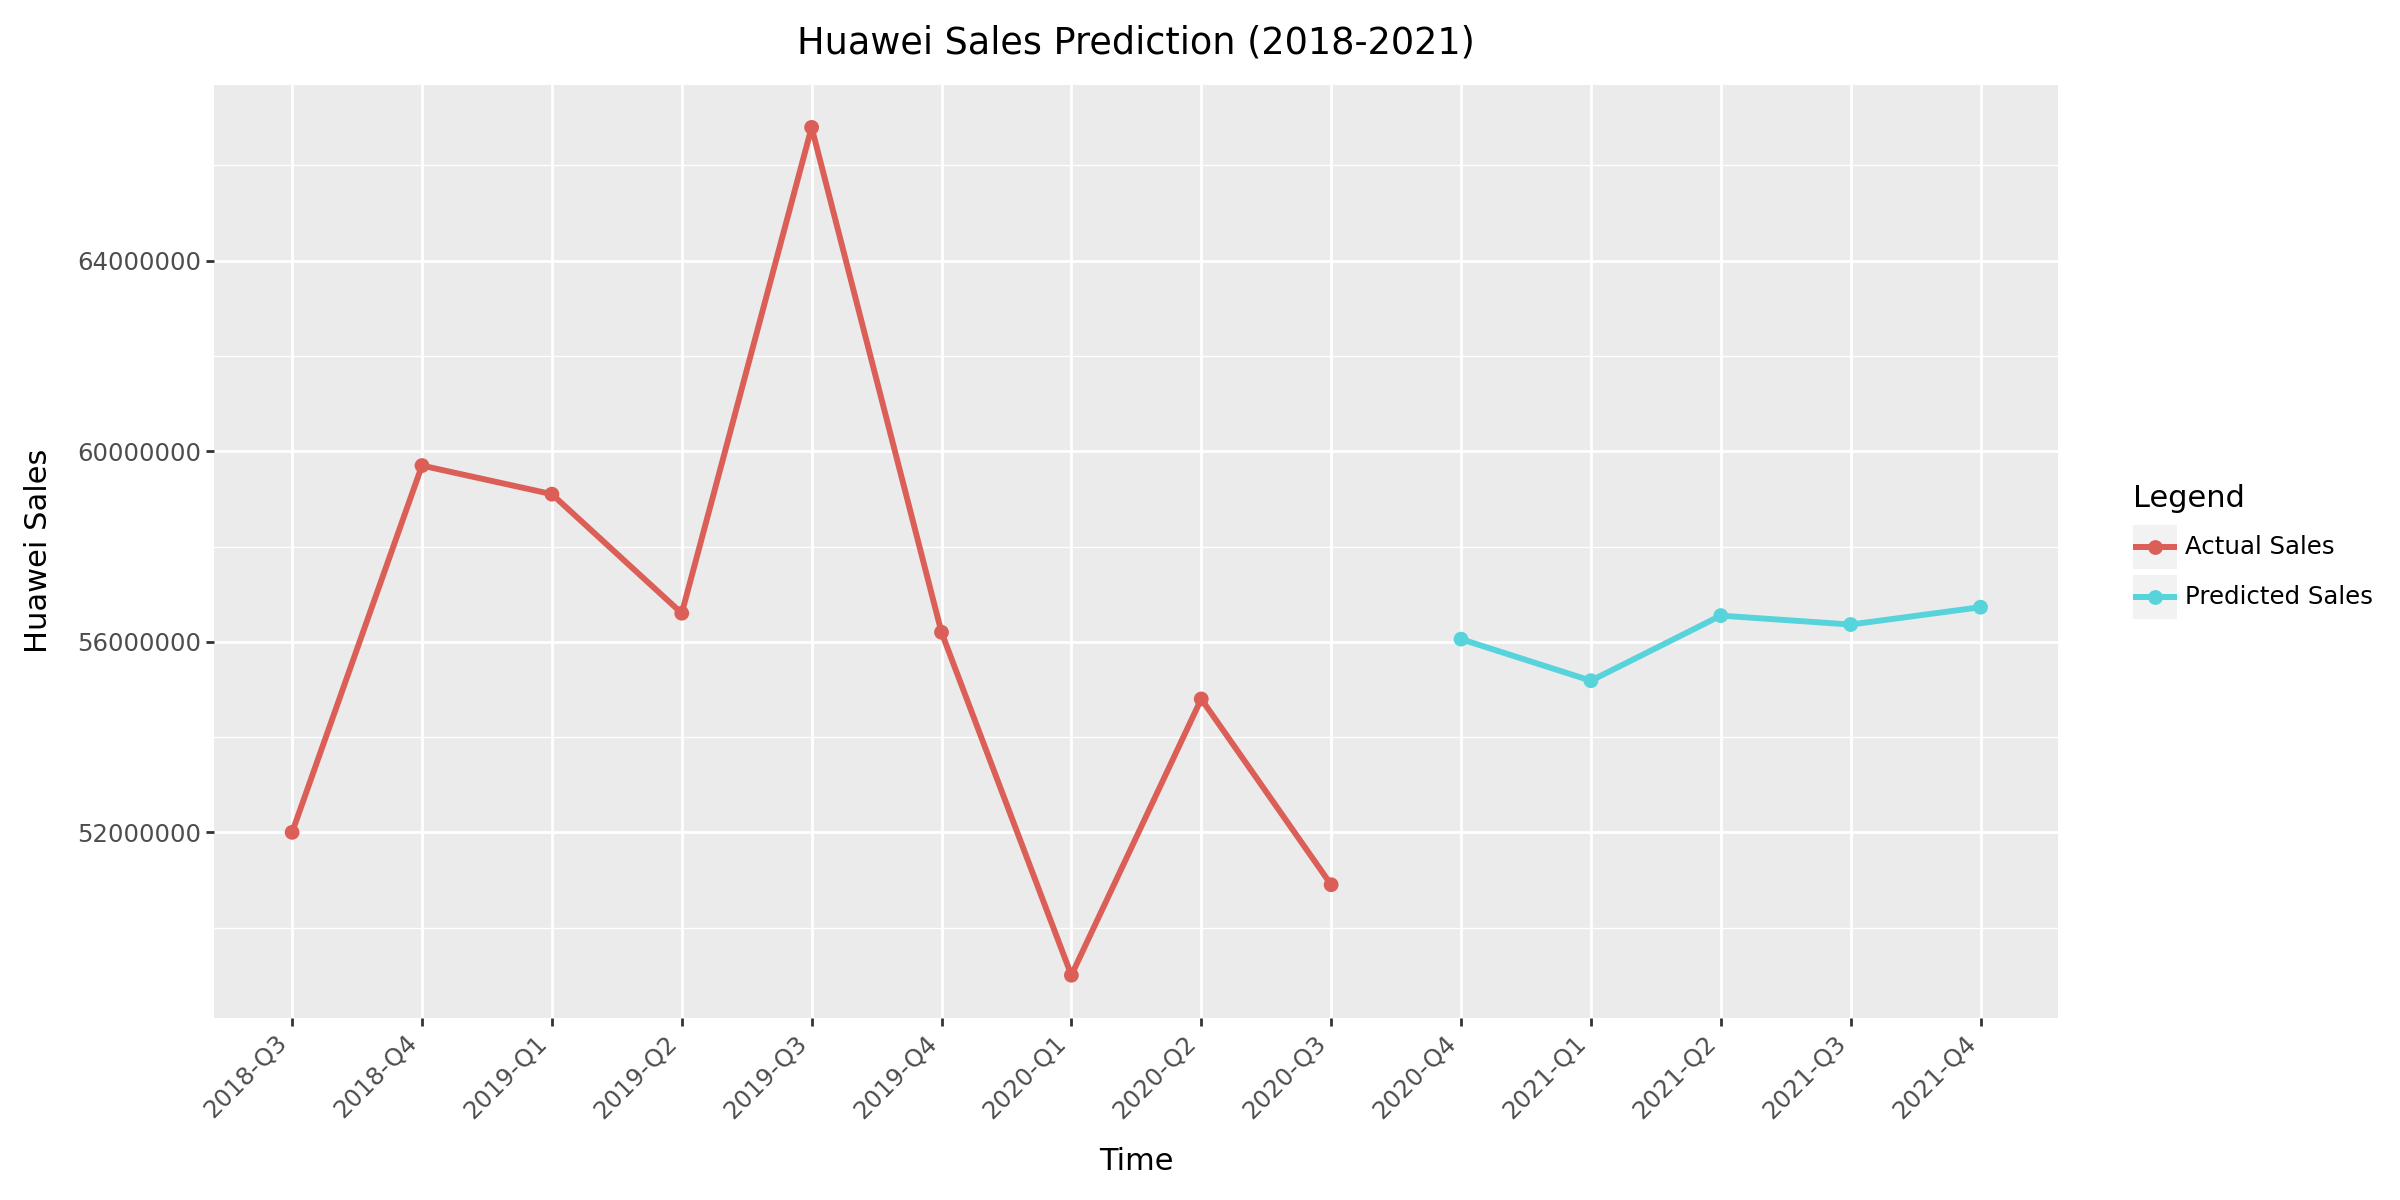

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Xiaomi RMSE: 1122648.6058425258
Xiaomi R2: 0.2857788827337947


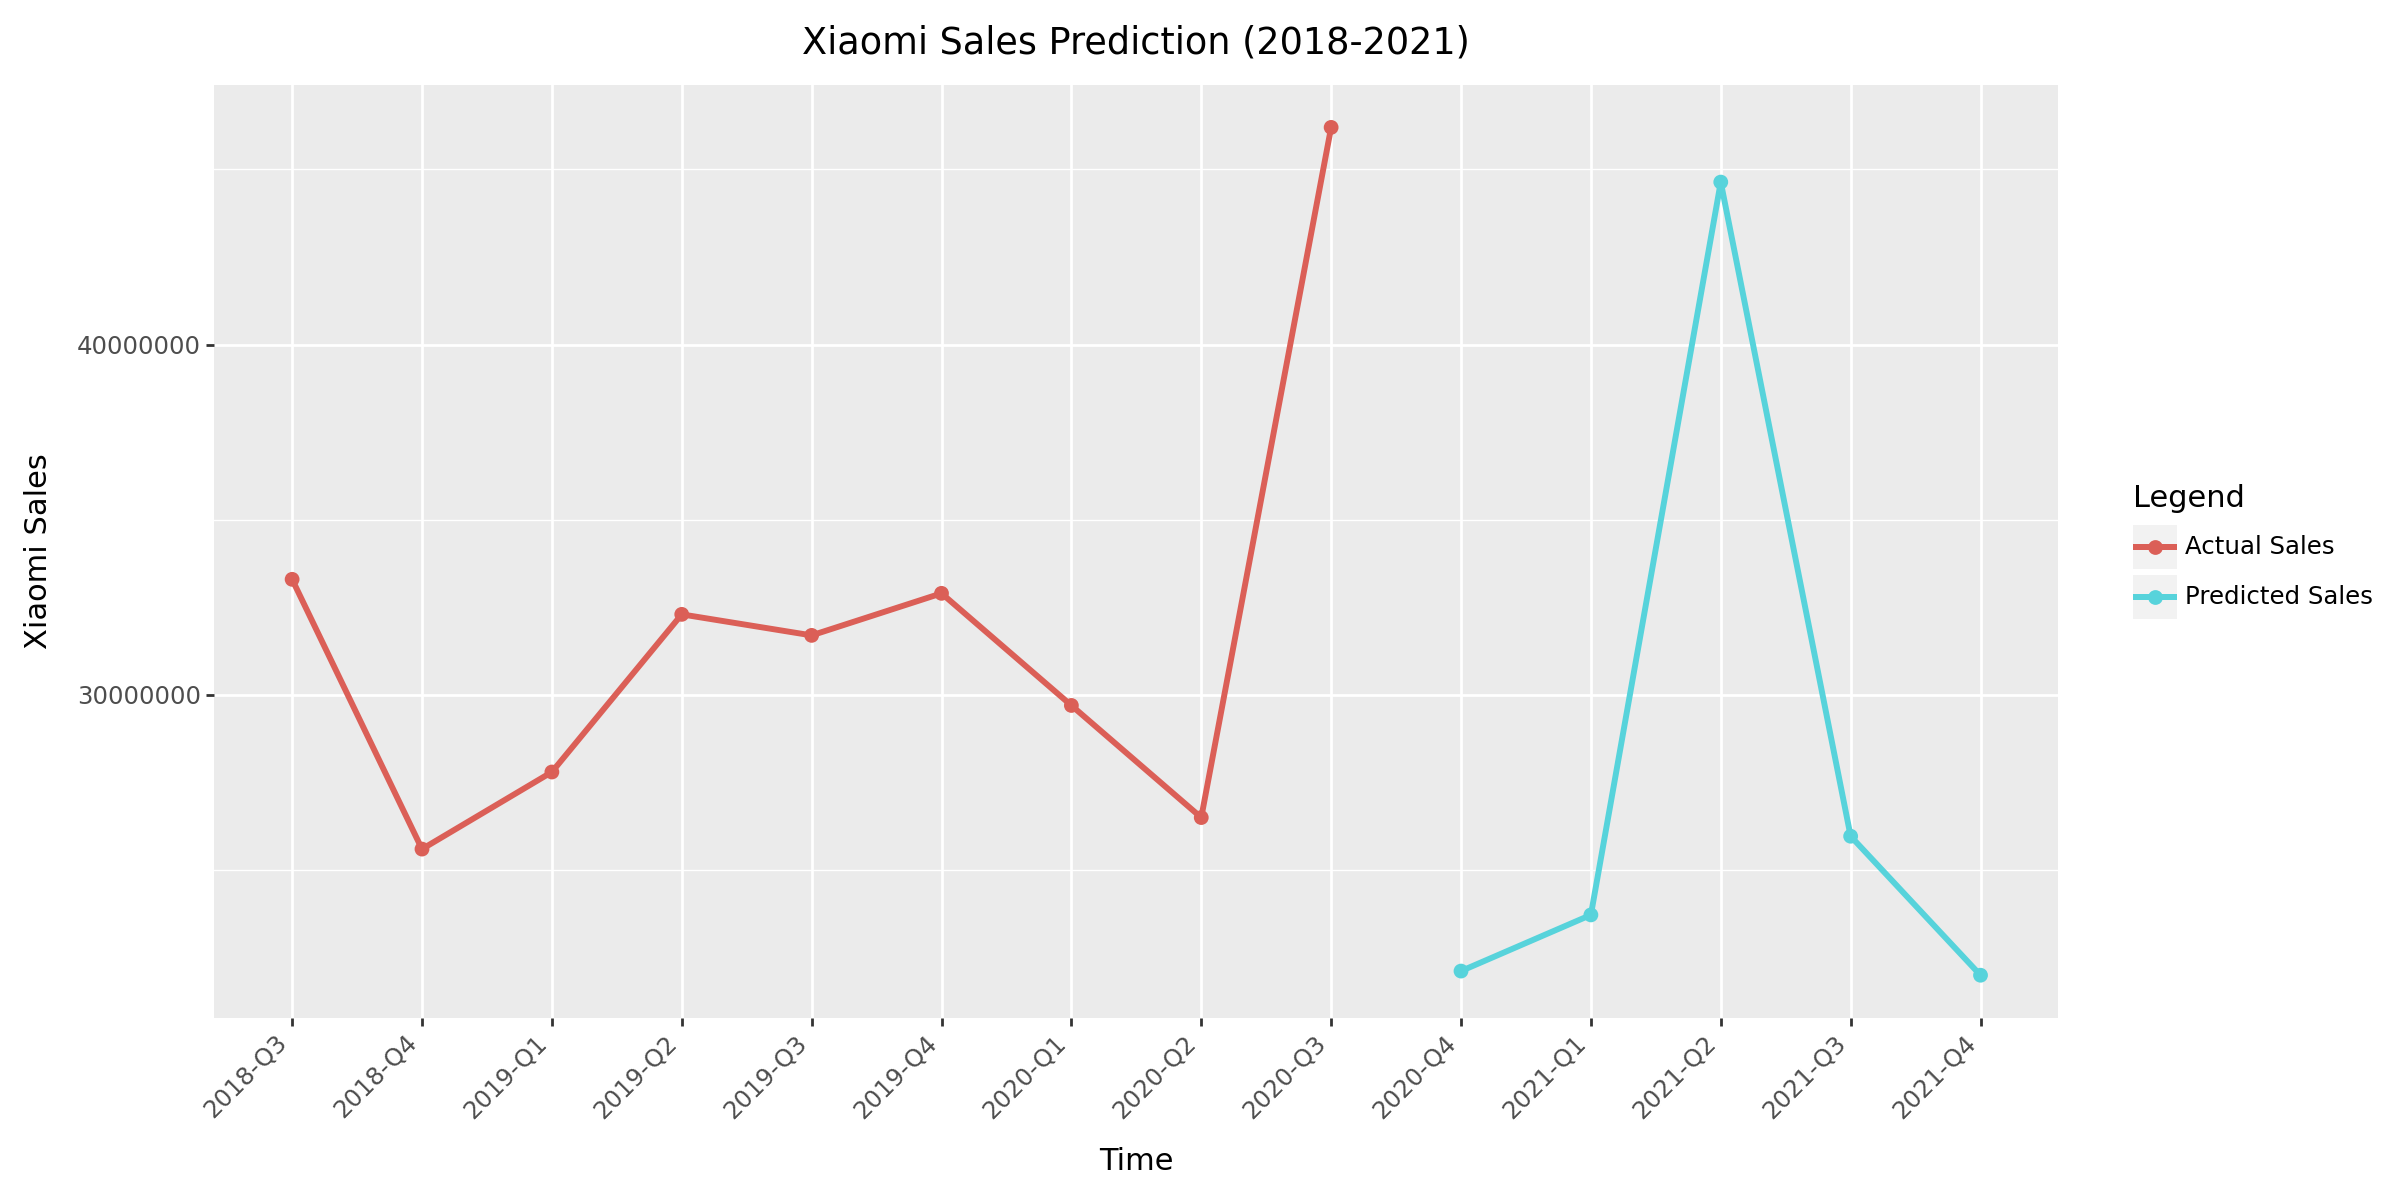

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Oppo RMSE: 4720564.535936435
Oppo R2: 0.6903798699041592


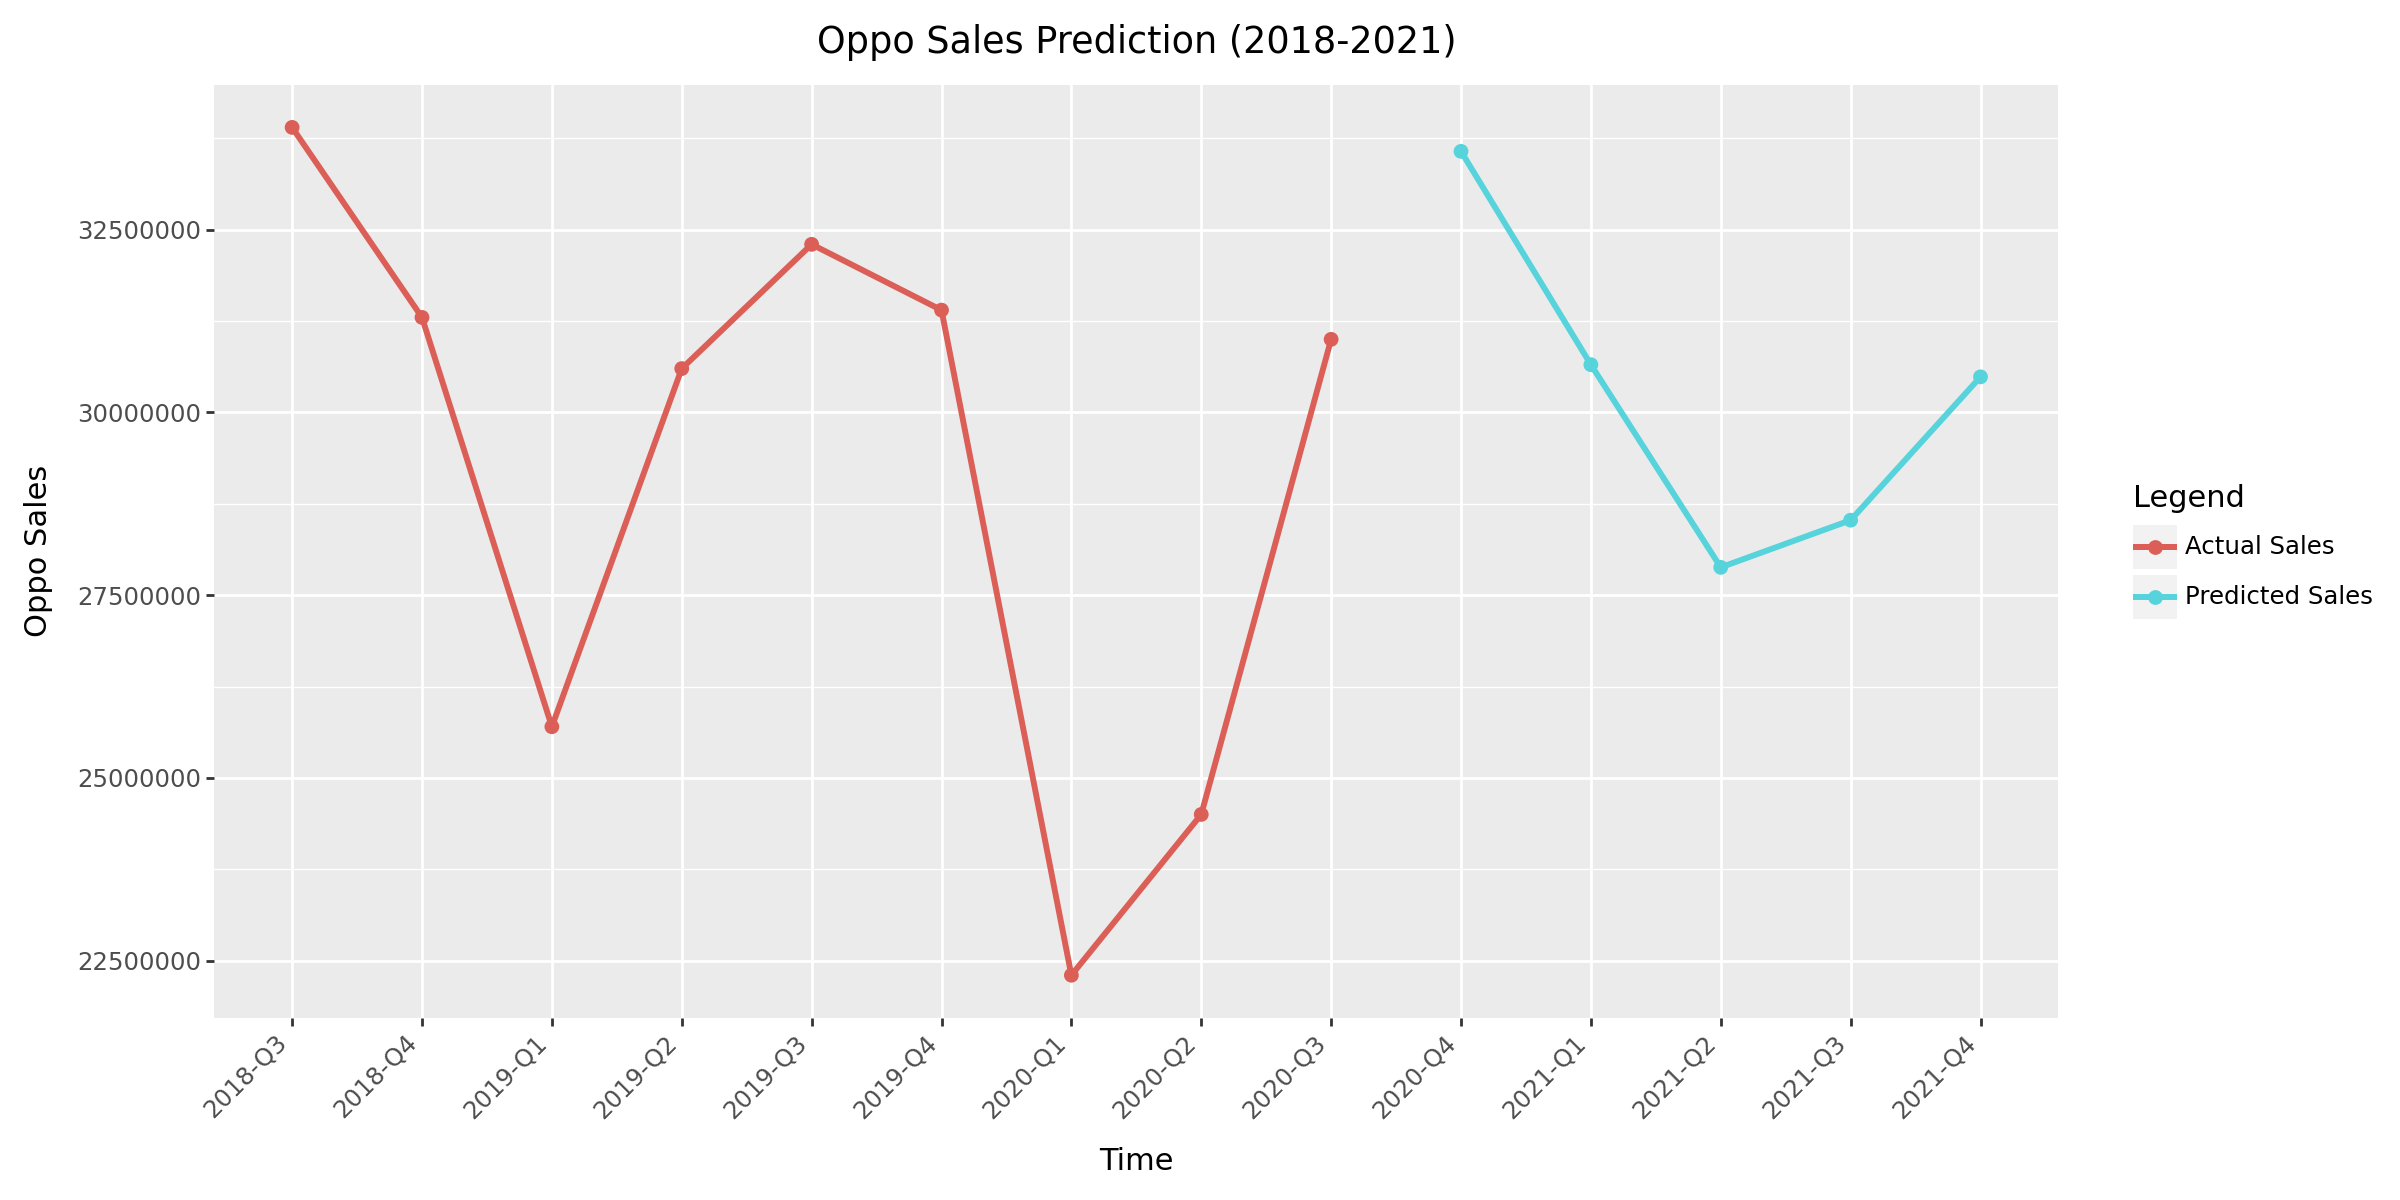

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Vivo RMSE: 3371664.2364489855
Vivo R2: 0.7354599884547852


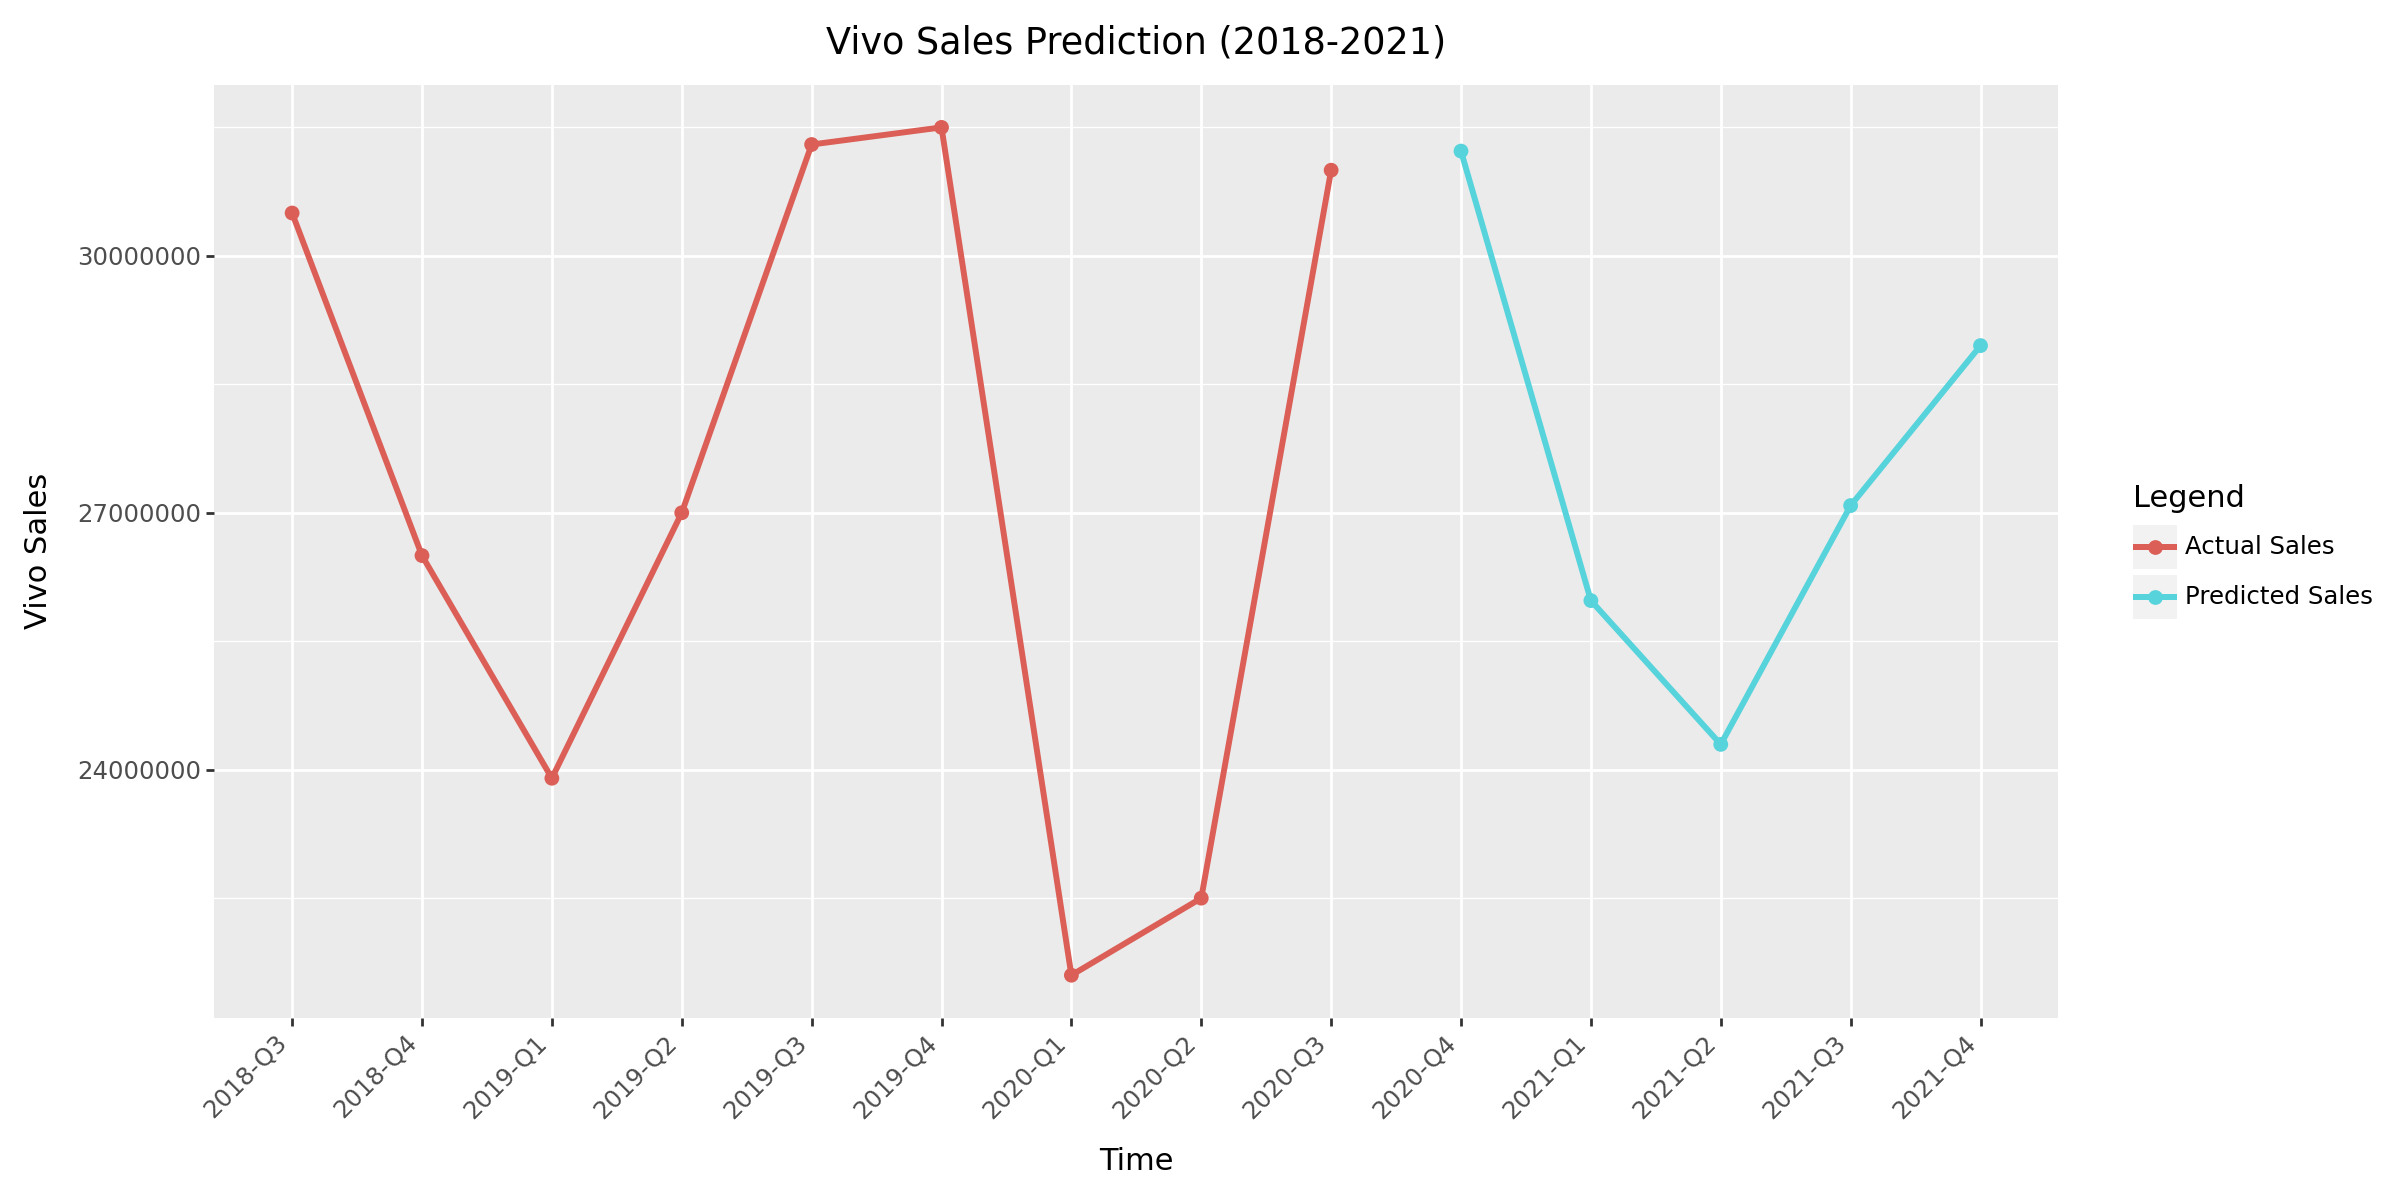

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Others RMSE: 29752164.036681604
Others R2: 0.5081169905757812


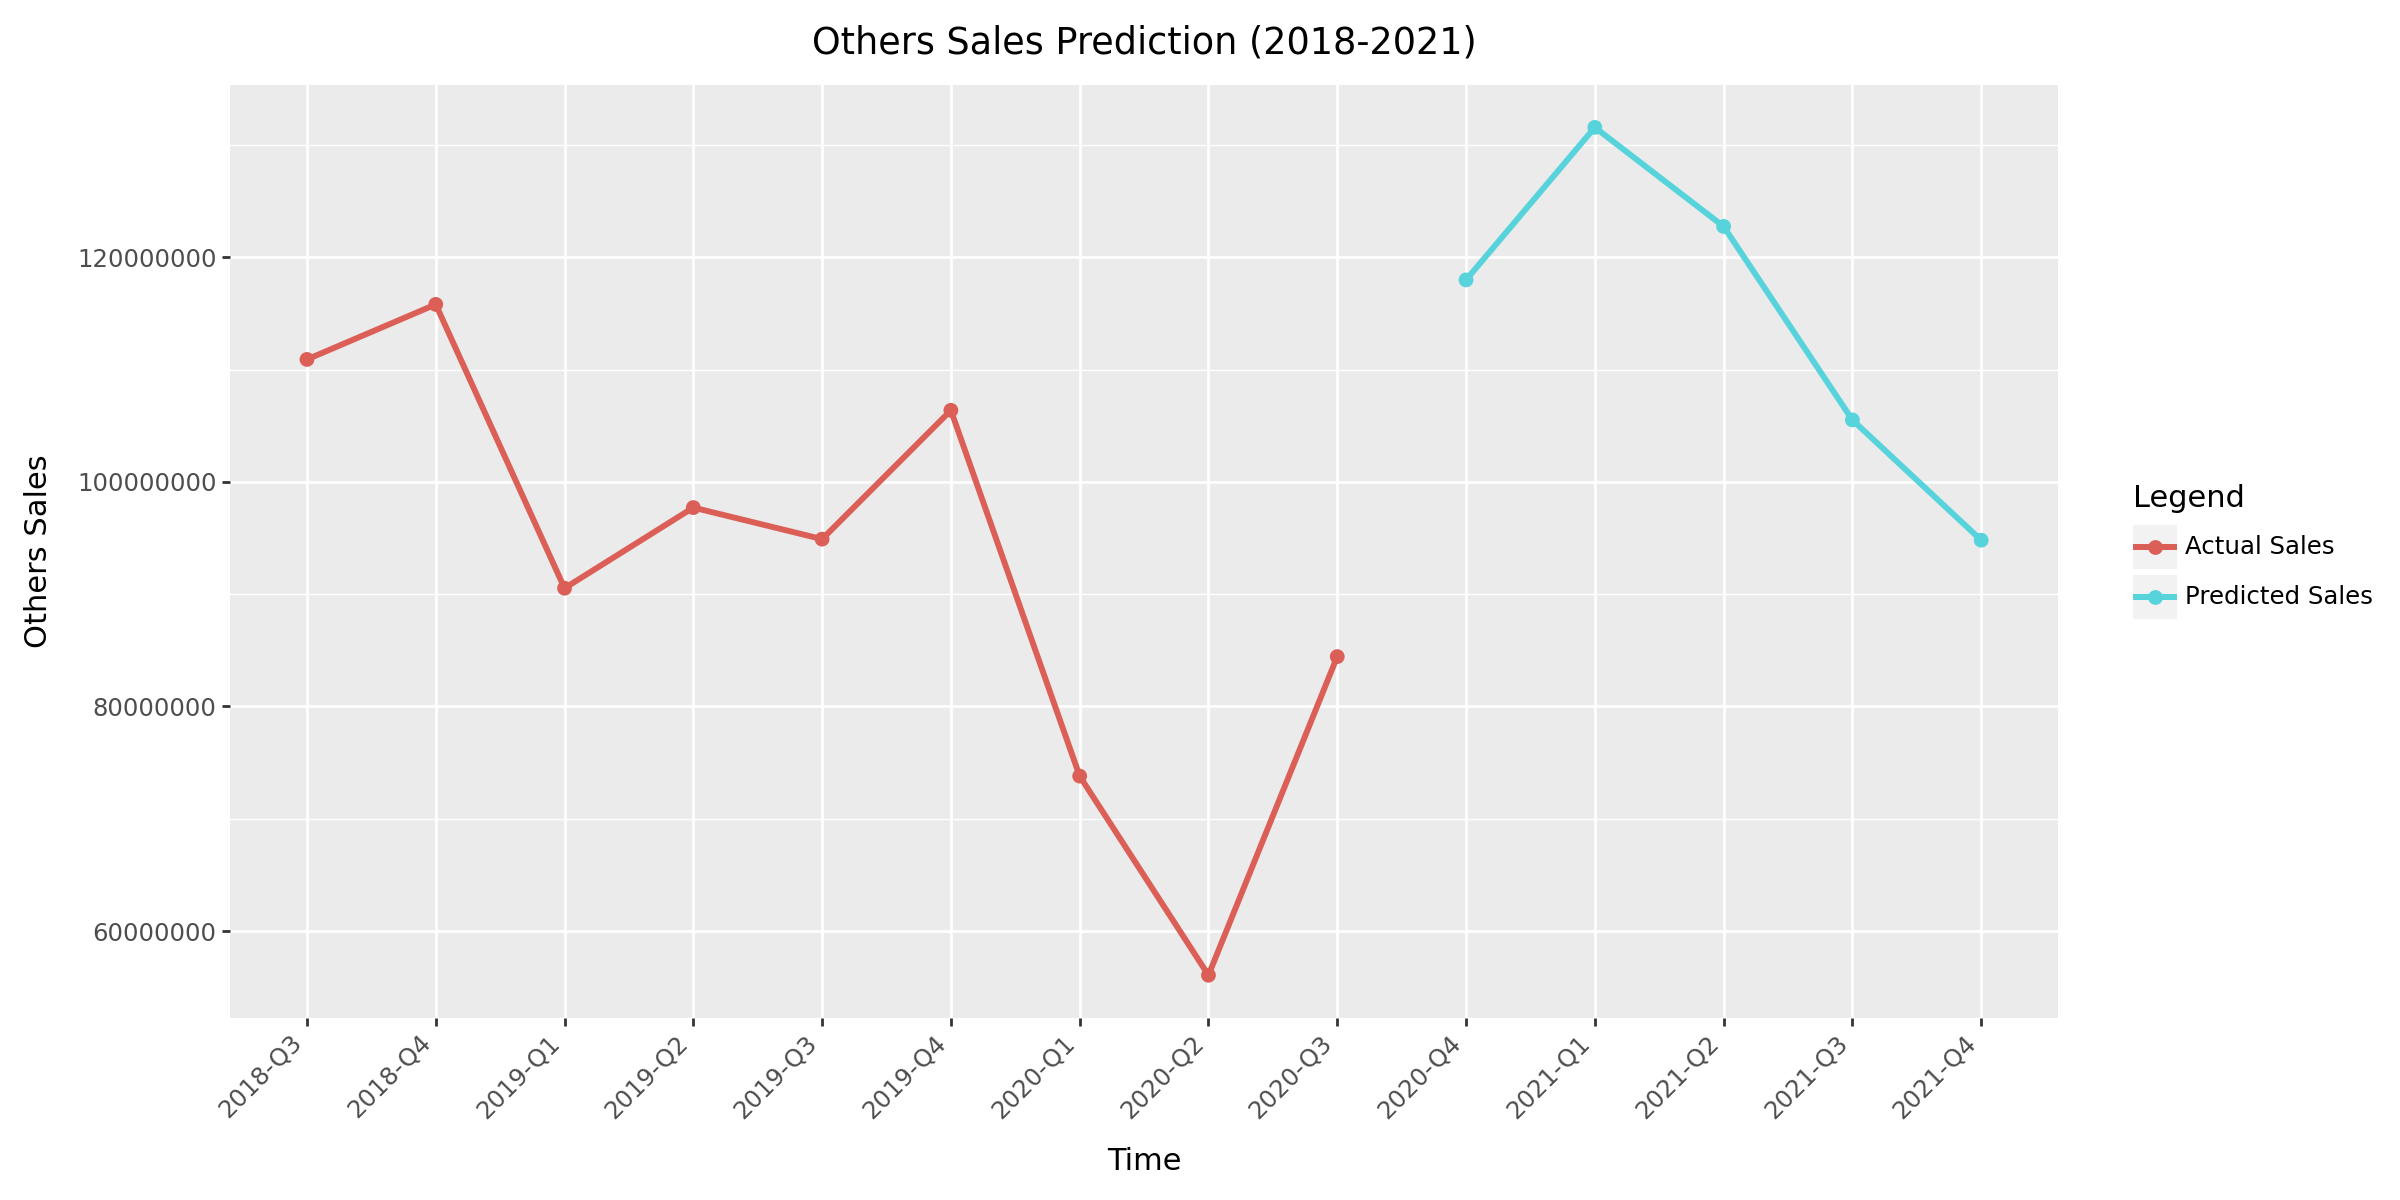

In [ ]:
def predict_company_sales(sales, company):
    company_features = sales[['Year', 'Quarter', company]]
    company_model = company_features.copy()
    company_model[f'{company}_Lag1'] = company_model[company].shift(1)
    company_model[f'{company}_Lag2'] = company_model[company].shift(2)
    company_model.dropna(inplace=True)
    company_model[f'{company}_Lag1'] = company_model[f'{company}_Lag1'].astype(int)
    company_model[f'{company}_Lag2'] = company_model[f'{company}_Lag2'].astype(int)

    X = company_model[[f'{company}_Lag1', f'{company}_Lag2']]
    y = company_model[company]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

    model = LinearRegression()
    model.fit(X_train, y_train)

    future_quarters = pd.DataFrame({
        'Year': [2020] * 1 + [2021] * 4,
        'Quarter': [4] + [1, 2, 3, 4],
        f'{company}_Lag1': [company_model[company].iloc[-1], np.nan, np.nan, np.nan, np.nan],
        f'{company}_Lag2': [company_model[company].iloc[-2], company_model[company].iloc[-1], np.nan, np.nan, np.nan]
    })

    for i in range(len(future_quarters)):
        if i > 0:
            future_quarters.loc[i, f'{company}_Lag1'] = future_quarters.loc[i - 1, 'Predicted']
            future_quarters.loc[i, f'{company}_Lag2'] = future_quarters.loc[i - 1, f'{company}_Lag1']
        future_quarters.loc[i, 'Predicted'] = model.predict(
            future_quarters[[f'{company}_Lag1', f'{company}_Lag2']].iloc[i:i+1]
        )[0]

    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_train, model.predict(X_train))
    print(f"{company} RMSE: {rmse}")
    print(f"{company} R2: {r2}")

    future_quarters[company] = np.nan
    df_combined = pd.concat([company_model, future_quarters], ignore_index=True)
    df_combined['Time'] = df_combined['Year'].astype(str) + '-Q' + df_combined['Quarter'].astype(str)
    df_combined['Type'] = np.where(df_combined[company].isna(), 'Predicted Sales', 'Actual Sales')
    df_combined['Sales'] = df_combined[company].fillna(df_combined['Predicted'])

    company_plot = (
        ggplot(df_combined, aes(x="Time", y="Sales", color="Type", group="Type"))
        + geom_line(size=1.2)
        + geom_point(size=2)
        + labs(
            title=f"{company} Sales Prediction (2018-2021)",
            x="Time",
            y=f"{company} Sales",
            color="Legend"
        )
        + theme(
            axis_text_x=element_text(rotation=45, hjust=1),
            figure_size=(12, 6)
        )
    )
    return company_plot

companies = ['Samsung', 'Huawei', 'Xiaomi', 'Oppo', 'Vivo', 'Others']
for company in companies:
    plot = predict_company_sales(sales, company)
    display(plot)
